# Problem Statement

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# Installing and Importing the necessary libraries

In [125]:
# Library for data manipulation and analysis.
import pandas as pd
# Fundamental package for scientific computing.
import numpy as np
#splitting datasets into training and testing sets.
from sklearn.model_selection import train_test_split
#Imports tools for data preprocessing including label encoding, one-hot encoding, and standard scaling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
#Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer
#Imports the Matplotlib library for creating visualizations.
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Imports the Seaborn library for statistical data visualization.
import seaborn as sns
# Time related functions.
import time
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
#Imports metrics from
from sklearn import metrics

#Imports the tensorflow,keras and layers.
import tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Input, Dropout,BatchNormalization
from tensorflow.keras import backend
# To be used for missing value imputation
from sklearn.impute import SimpleImputer

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
    StackingClassifier
)
from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report
)

# To build model for statistical analysis and prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To be used for creating pipelines and personalizing them
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# To define maximum number of columns and rows to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Loading the Data

In [126]:
# Point these to wherever your CSVs live:
#  - Colab + Drive:   '/content/drive/MyDrive/Train.csv'
#  - Kaggle:          '/kaggle/input/<your-dataset-folder>/Train.csv'
#  - Local/dummy run: 'Train_DUMMY.csv' / 'Test_DUMMY.csv' (synthetic data, safe to share/run)
TRAIN_PATH = '/kaggle/input/datasets/w683kcevnqg6/rewind-train-and-test/Train.csv'  # <-- change this to your real path when available
TEST_PATH = '/kaggle/input/datasets/w683kcevnqg6/rewind-train-and-test/Test.csv'    # <-- change this to your real path when available

df = pd.read_csv(TRAIN_PATH)    # Complete the code to import the training data
df_test = pd.read_csv(TEST_PATH)    # Complete the code to import the test data

# Data Overview

# Checking the shape of the dataset

In [127]:
# Checking the number of rows and columns in the training data
df.shape

(20000, 41)

Observations

The output `df.shape` shows:

- 20,000 rows: This means the dataset has 20,000 individual records/observations.
- 41 columns: There are 40 predictor variables (V1-V40) plus 1 target variable.

In [128]:
# Checking the number of rows and columns in the test data
df_test.shape

(5000, 41)

Observations

The output `df_test.shape` indicates:

- 5,000 rows: The test dataset contains 5,000 individual records.
- 41 columns: It has the same number of features as the training dataset (40 predictors + Target).

In [129]:
# let's create a copy of the training data
data = df.copy()

In [130]:
# let's create a copy of the testing  data
data_test = df_test.copy()

# Displaying the first few rows of the dataset

In [131]:
# let's check the data types of the columns in the dataset
data.dtypes

V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
V29       float64
V30       float64
V31       float64
V32       float64
V33       float64
V34       float64
V35       float64
V36       float64
V37       float64
V38       float64
V39       float64
V40       float64
Target      int64
dtype: object

In [132]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

Summary of Training Data (`data`):

- Total entries: 20,000
- Total columns: 41
- Feature columns: V1 to V40 (40 features, float64)
- Target column: Target (int64, converted to float64)
- Missing data: only V1 and V2 have missing values (18 each) — <0.1% of the data. All other columns are complete.

Converting Target column to float

In [133]:
data['Target'] = data['Target'].astype(float)

Now checking for test data

In [134]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

Summary of Test Data (`data_test.info()`):

- Total entries: 5,000
- Total columns: 41
- Feature columns: V1 to V40 (float64)
- Target column: Target (int64, converted to float64)
- Missing data: only V1 (5 missing) and V2 (6 missing) have missing values. All other columns are complete.

Converting Target to float

In [135]:
data_test['Target'] = data_test['Target'].astype(float)

# Checking for duplicate values

In [136]:
data.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
19995    False
19996    False
19997    False
19998    False
19999    False
Length: 20000, dtype: bool

In [137]:
data.duplicated().sum()

np.int64(0)

The output of data.duplicated().sum() means

✅ There are no duplicate rows in your dataset (data).

In [138]:
data.isnull().sum()

V1        18
V2        18
V3         0
V4         0
V5         0
V6         0
V7         0
V8         0
V9         0
V10        0
V11        0
V12        0
V13        0
V14        0
V15        0
V16        0
V17        0
V18        0
V19        0
V20        0
V21        0
V22        0
V23        0
V24        0
V25        0
V26        0
V27        0
V28        0
V29        0
V30        0
V31        0
V32        0
V33        0
V34        0
V35        0
V36        0
V37        0
V38        0
V39        0
V40        0
Target     0
dtype: int64

Summary: Missing Values in data

Only 2 columns have missing values :

V1: 18 missing

V2: 18 missing

All other 39 feature columns and the Target column are fully complete
(no nulls)

Total Missing:

36 missing values total, which is only 0.18% of your dataset (20,000 rows).

# Checking for missing values

In [139]:
data_test.isnull().sum() #

V1        5
V2        6
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
V29       0
V30       0
V31       0
V32       0
V33       0
V34       0
V35       0
V36       0
V37       0
V38       0
V39       0
V40       0
Target    0
dtype: int64

Observations

Summary of missing values in the datasets:

**Training data:**
- V1: 18 missing
- V2: 18 missing
- All other 38 feature columns and the Target column are fully complete
- No duplicate rows (`data.duplicated().sum()` = 0)

**Test data:**
- V1: 5 missing
- V2: 6 missing
- All other columns complete

Missing data is minimal (well under 0.1% of rows) and limited to the same two feature columns in both datasets, so median imputation (as used later in this notebook) is a reasonable approach.

# Statistical summary of the dataset

In [140]:
data.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,19982.000,19982.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,0.030,-0.041,0.049,-0.033,-0.008,0.007,0.044,0.057,-0.011,0.004,0.020,-0.009,0.025,-0.017,0.068,0.019,-0.009,-0.004,0.009,-0.016,-0.039,0.121,0.002,-0.014,-0.012,0.007,-0.010,-0.050,-0.003,-0.003,0.023,0.013,0.003,0.006,0.010,0.022,0.009,0.012,0.010,-0.002,0.057
std,3.016,2.997,3.024,3.018,3.015,3.016,3.006,2.993,2.998,2.986,2.987,3.002,3.003,2.978,3.024,2.987,3.007,3.008,3.003,2.991,3.023,3.027,2.998,3.009,2.987,3.015,2.993,2.982,3.019,3.007,3.016,2.990,2.997,2.988,2.996,3.011,3.013,2.992,3.004,3.004,0.231
min,-12.000,-11.720,-11.664,-11.472,-11.438,-12.000,-10.841,-10.842,-12.000,-12.000,-12.000,-11.505,-11.729,-11.204,-11.834,-11.699,-11.252,-12.000,-12.000,-12.000,-12.000,-10.769,-12.000,-12.000,-12.000,-11.483,-11.006,-12.000,-12.000,-12.000,-12.000,-12.000,-12.000,-12.000,-11.298,-12.000,-12.000,-12.000,-12.000,-11.805,0.000
25%,-2.002,-2.038,-1.971,-2.084,-2.037,-2.019,-1.995,-1.960,-2.052,-2.000,-1.994,-2.035,-2.015,-2.036,-1.956,-1.973,-2.022,-2.008,-2.005,-2.039,-2.068,-1.903,-2.014,-2.046,-2.005,-2.040,-2.023,-2.049,-2.045,-2.030,-1.992,-2.006,-1.997,-1.983,-2.001,-2.010,-1.988,-1.984,-2.012,-2.001,0.000
50%,0.022,-0.051,0.009,-0.043,-0.034,0.003,0.049,0.034,0.027,0.023,0.024,0.007,0.001,-0.038,0.076,0.005,-0.002,0.005,-0.004,0.001,-0.040,0.115,-0.028,-0.014,-0.015,-0.014,0.011,-0.055,-0.006,-0.003,0.046,0.016,0.024,-0.001,-0.014,0.028,0.003,0.020,0.002,-0.025,0.000
75%,2.047,1.959,2.100,2.019,2.012,2.032,2.086,2.073,2.016,2.019,2.034,2.012,2.051,1.994,2.104,2.020,2.004,2.025,2.052,2.022,2.015,2.145,2.043,2.030,1.995,2.061,2.019,1.983,2.028,2.022,2.062,2.007,2.011,2.007,2.030,2.081,2.047,2.033,2.051,2.024,0.000
max,12.981,15.022,12.085,13.520,12.135,13.755,11.937,14.734,14.980,12.269,12.227,11.978,12.655,14.019,12.010,11.060,12.433,11.331,11.949,13.385,12.167,11.592,11.890,11.960,12.204,11.708,10.887,11.590,13.043,12.487,11.739,11.416,13.251,12.158,11.029,11.071,12.588,12.078,12.491,10.889,1.000


Here’s the descriptive statistics summary in clear points:

Data Size:

About 20,000 rows for each feature (V1 and V2 have 19,982 due to missing values).

Means:

Feature means vary; e.g.,

V1 mean ≈ -0.27

V2 mean ≈ 0.44

Other features have varying means.

Standard Deviations:

Vary widely across features, indicating different data spreads.

Minimum Values:

Features have large negative minimums (e.g., V1 min ≈ -11.88, V2 min ≈ -12.32).

Quartiles:

25th percentile values mostly negative for many features.

Medians (50%) close to zero or slightly negative/positive.

75th percentiles mostly positive, showing skewness in features.

Maximum Values:

Features show large positive extremes (e.g., V1 max ≈ 15.49, V2 max ≈ 13.09).

Target Column:

Appears binary with min, median, max values of 0 (likely 0/1 classification target).

Missing Data Impact:

V1 and V2 have slightly fewer counts due to missing data.

Implication:

Features have varied scales and skewness — scaling or normalization might be needed before modeling.

# Exploratory Data Analysis

## Univariate analysis

In [141]:
# function to plot a boxplot and a histogram along the same scale

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

# Variables V1 to V29

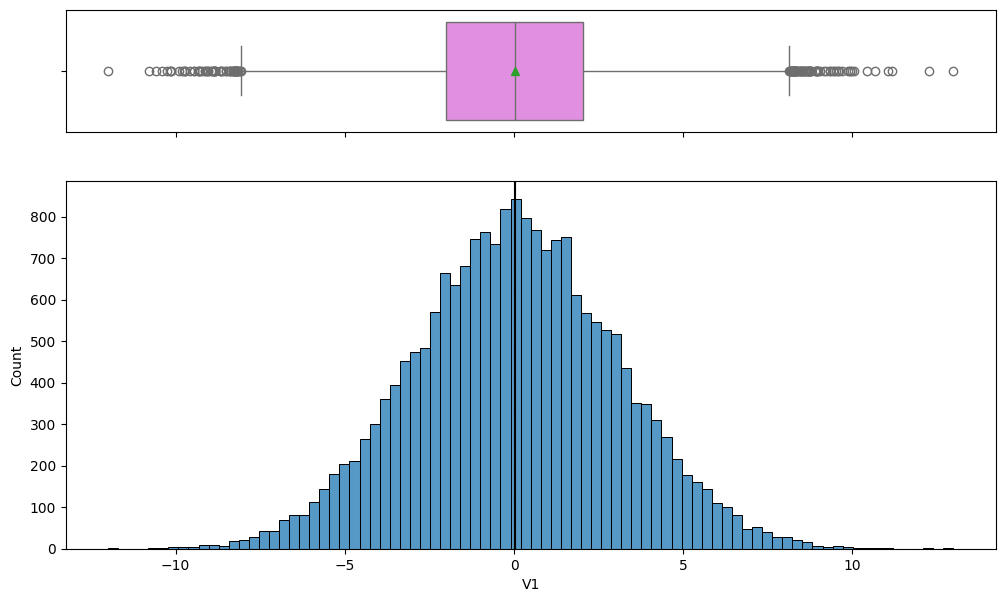

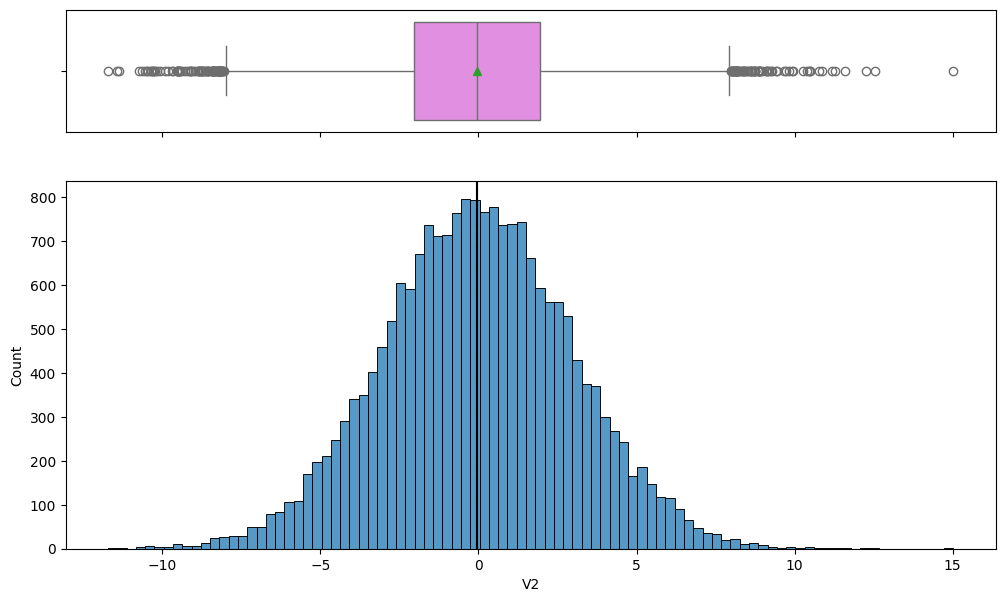

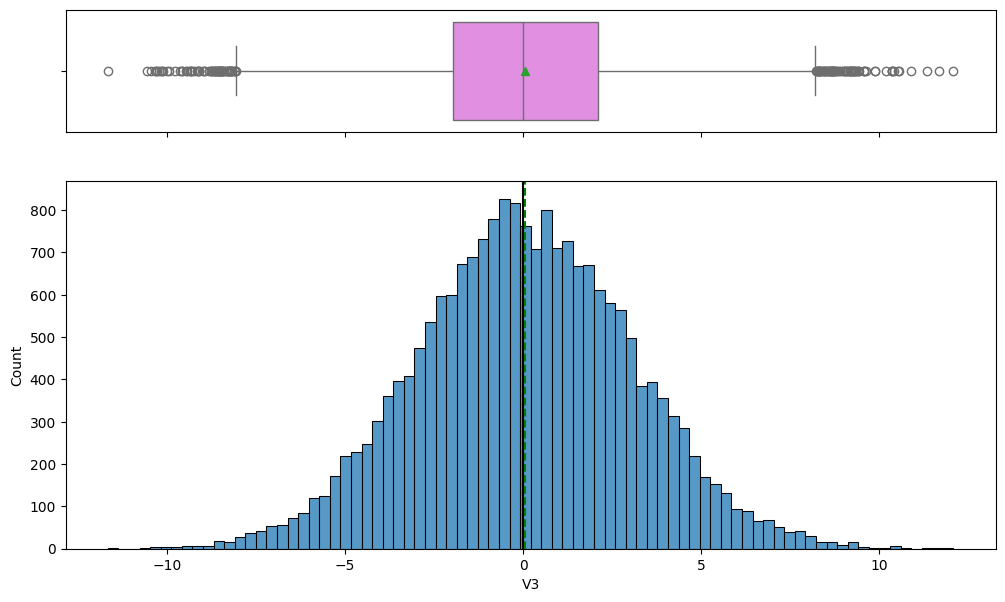

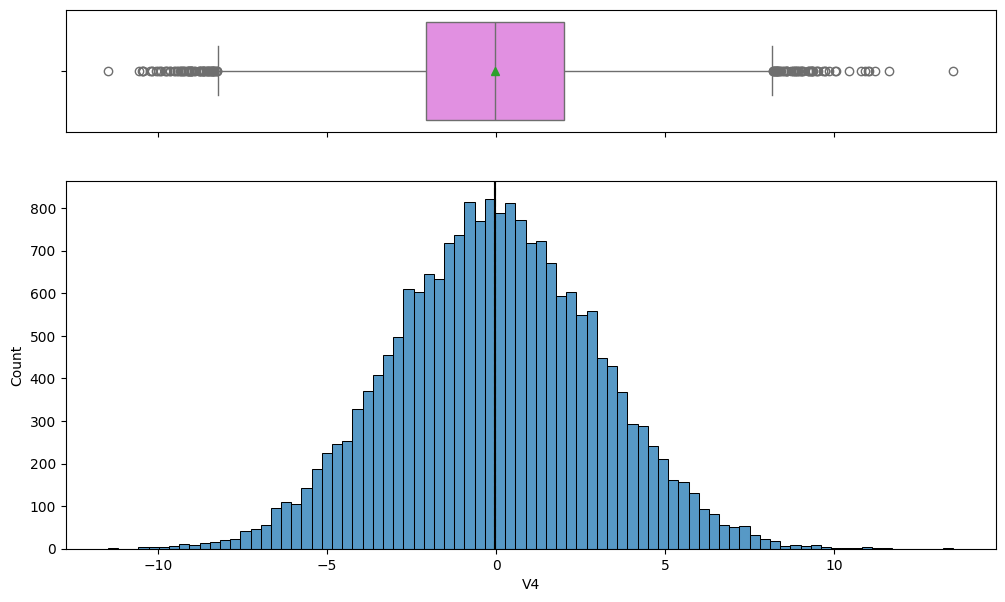

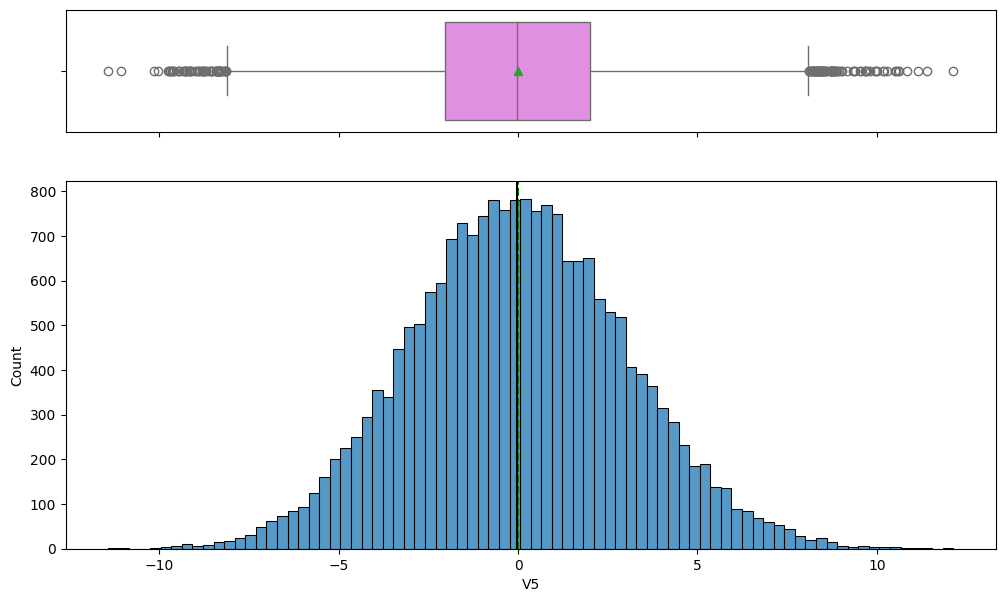

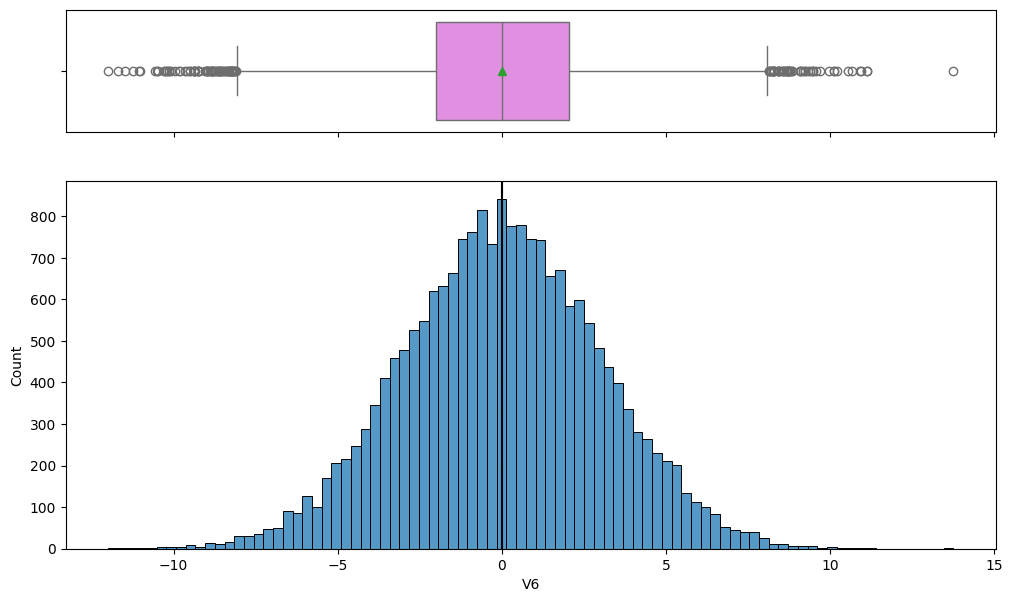

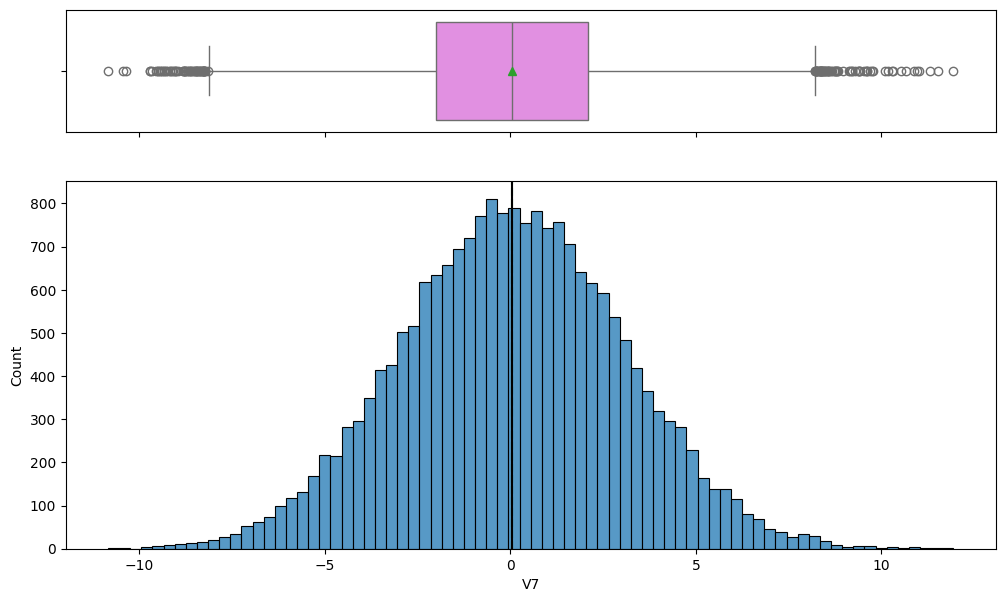

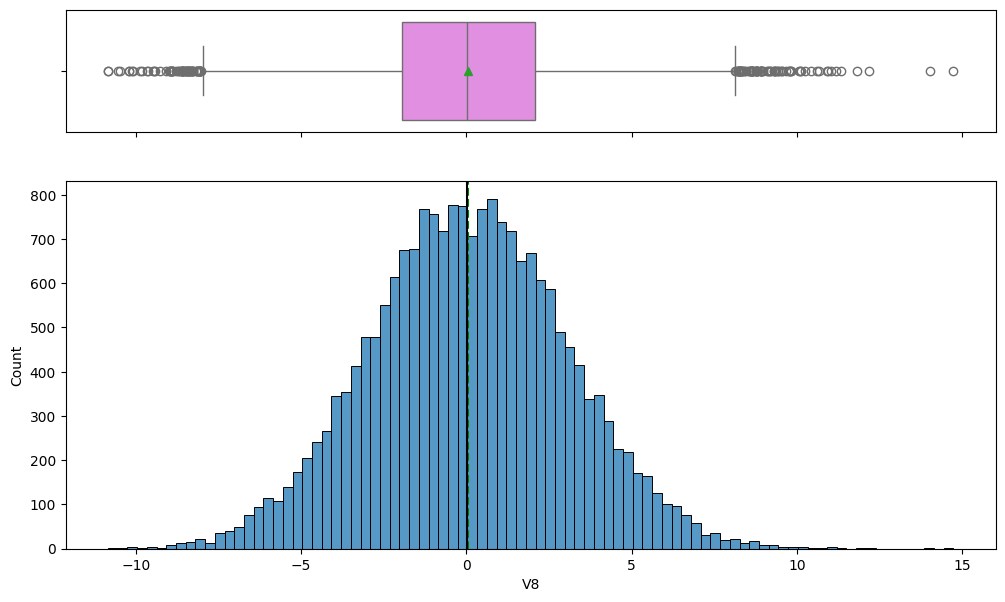

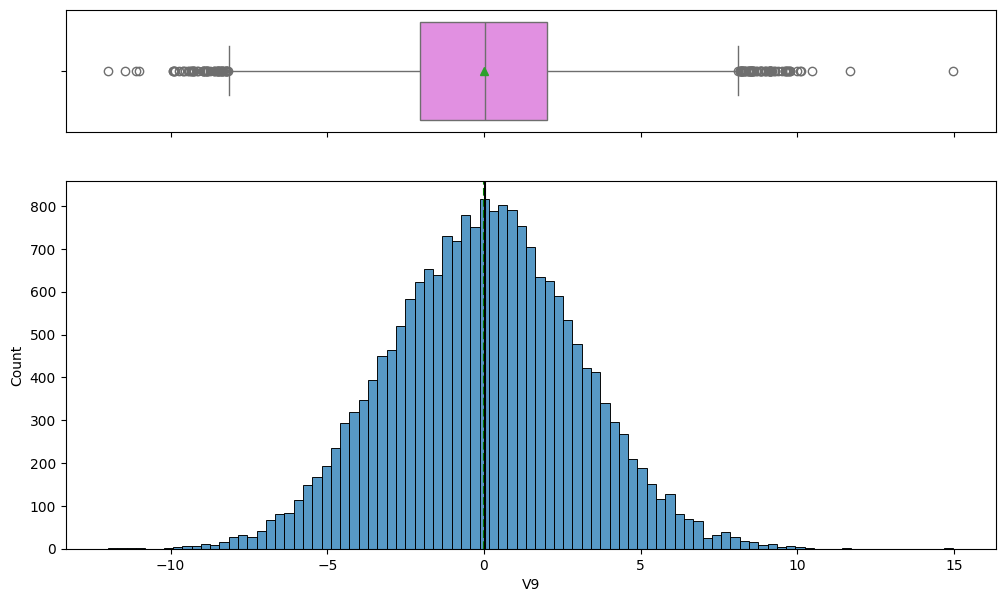

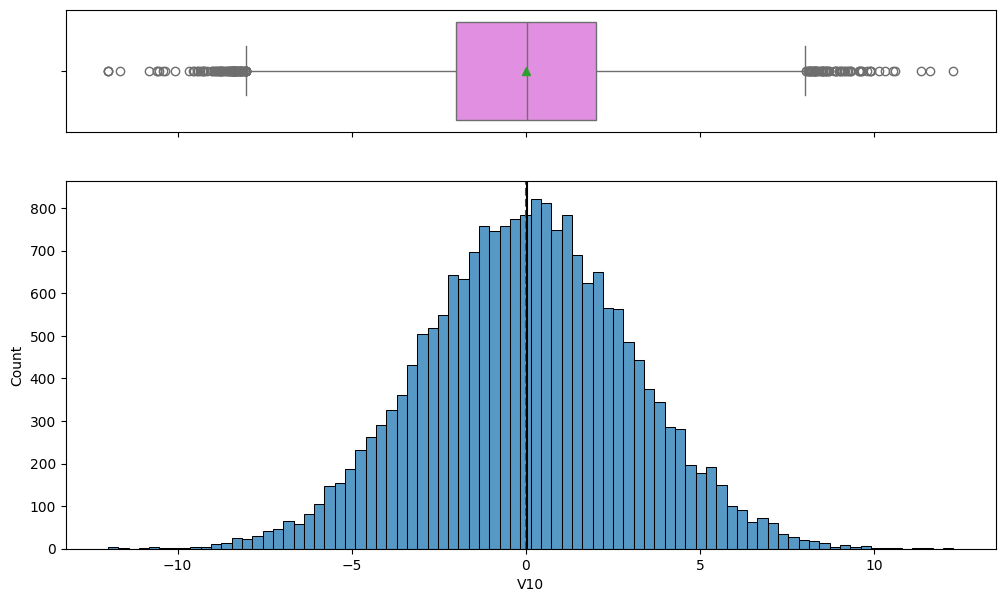

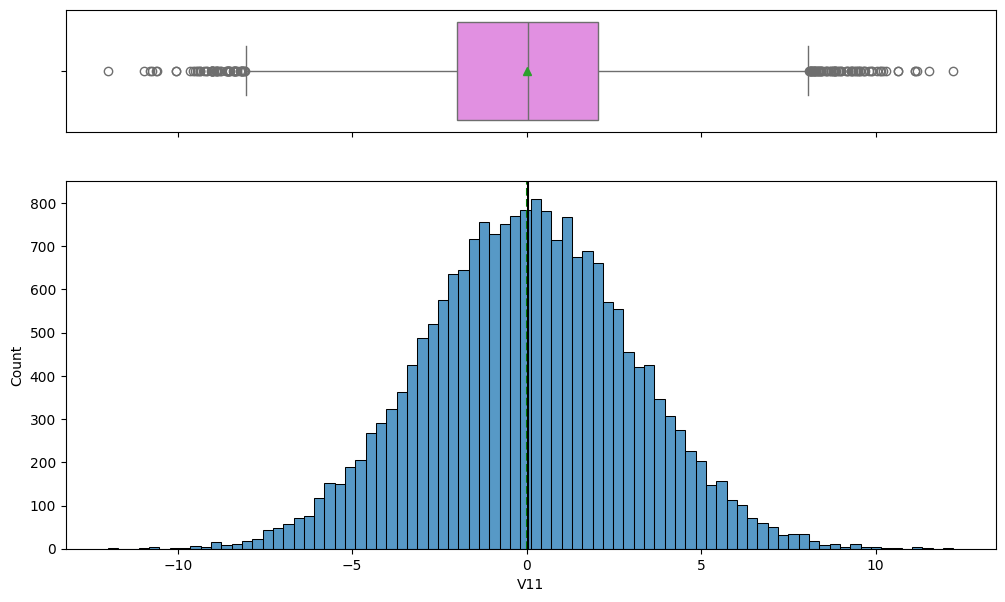

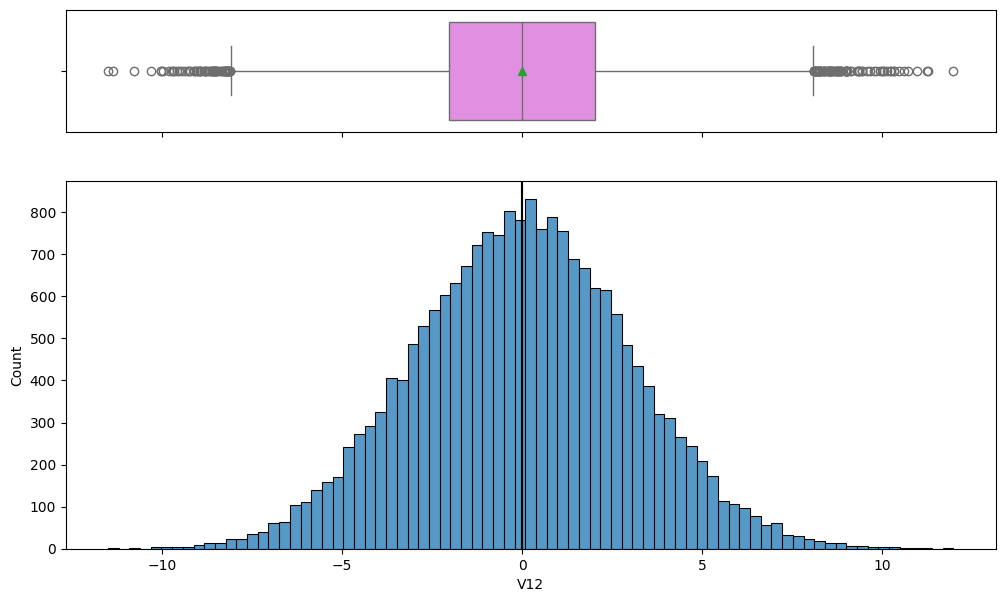

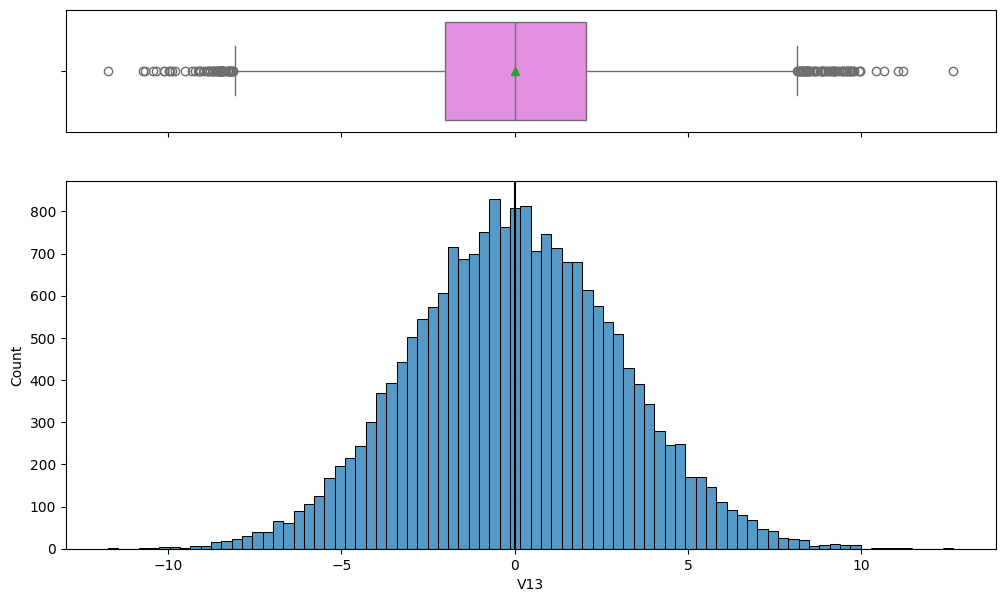

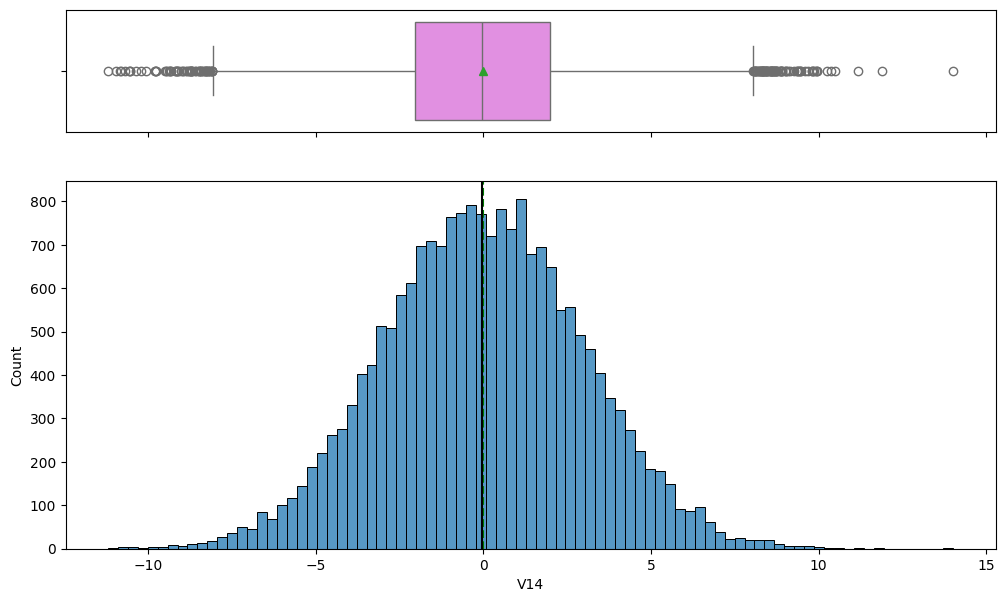

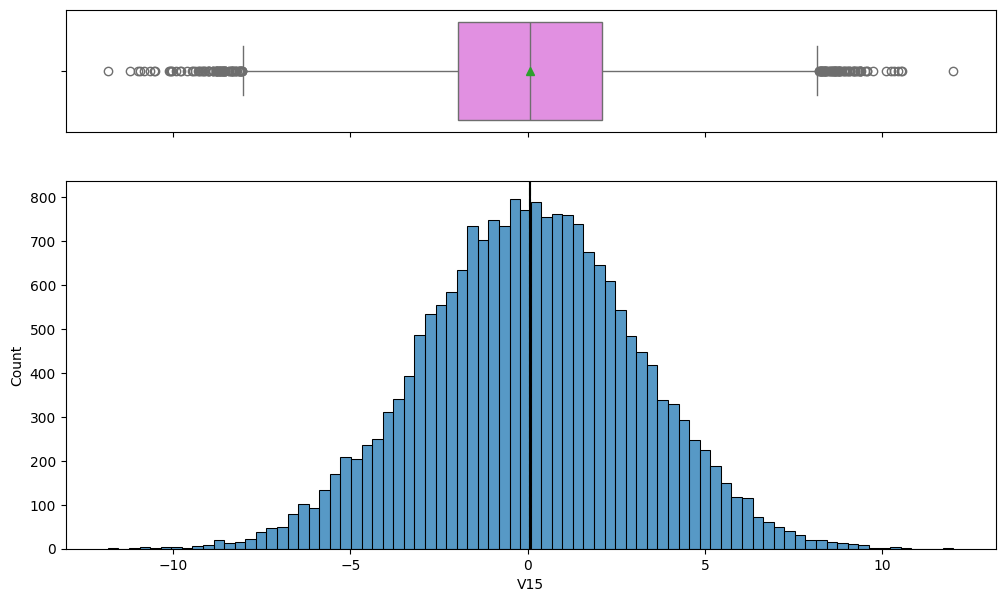

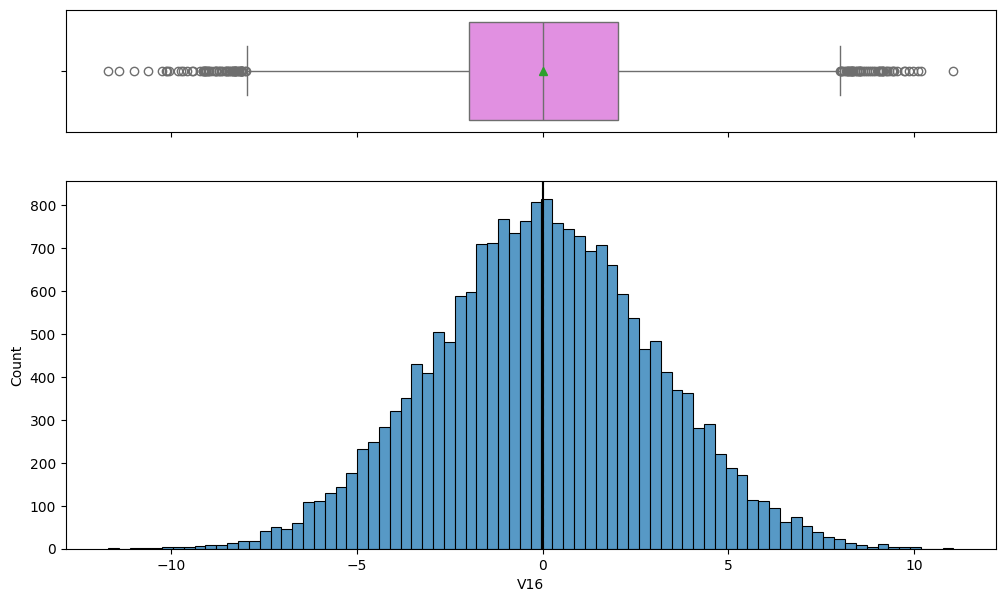

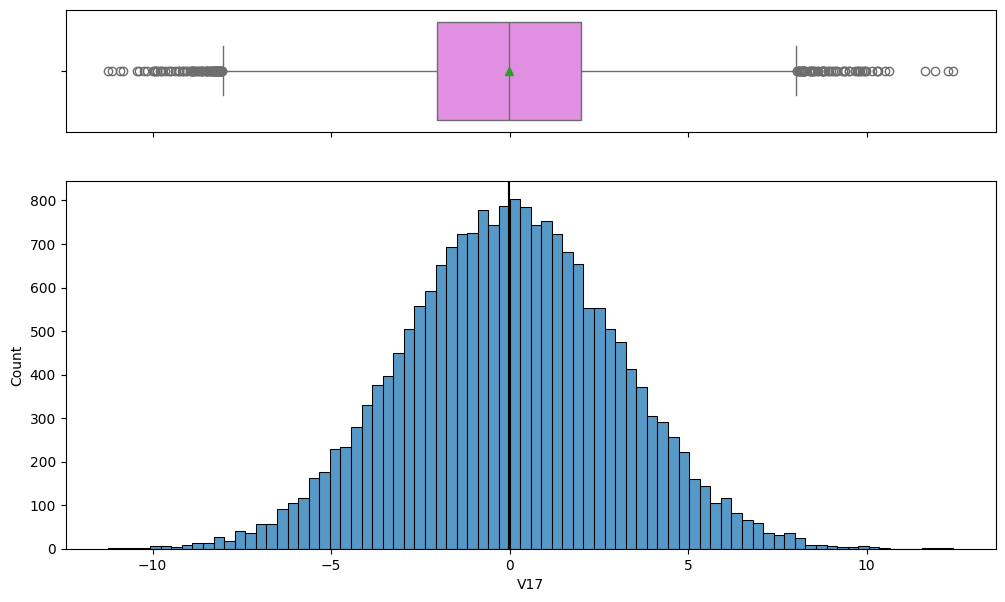

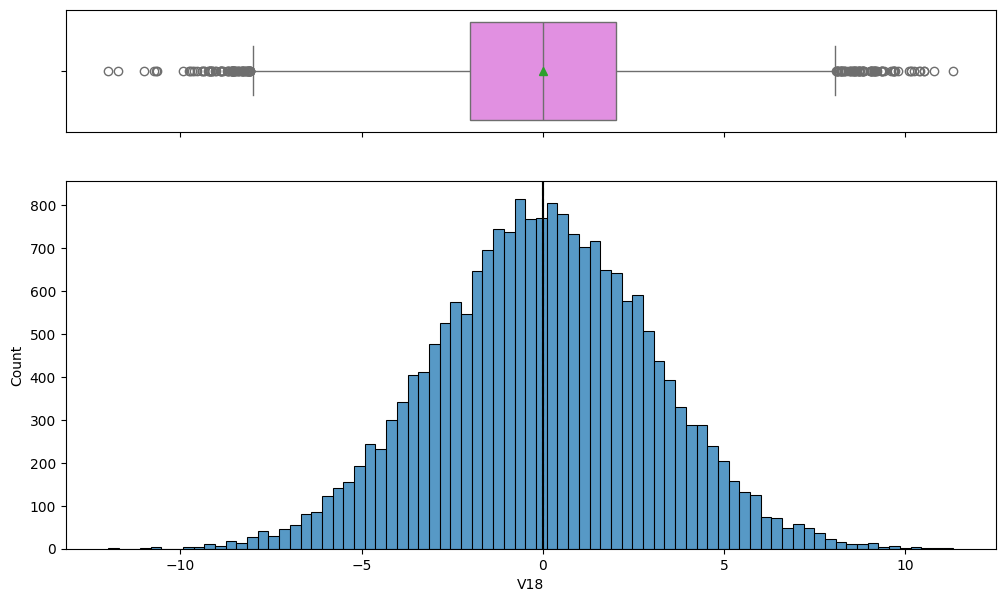

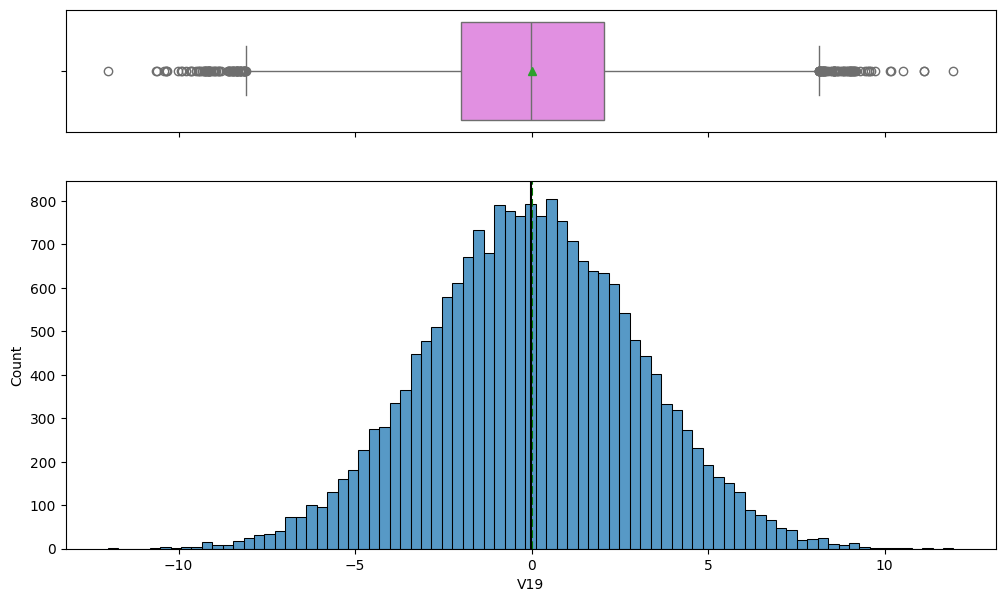

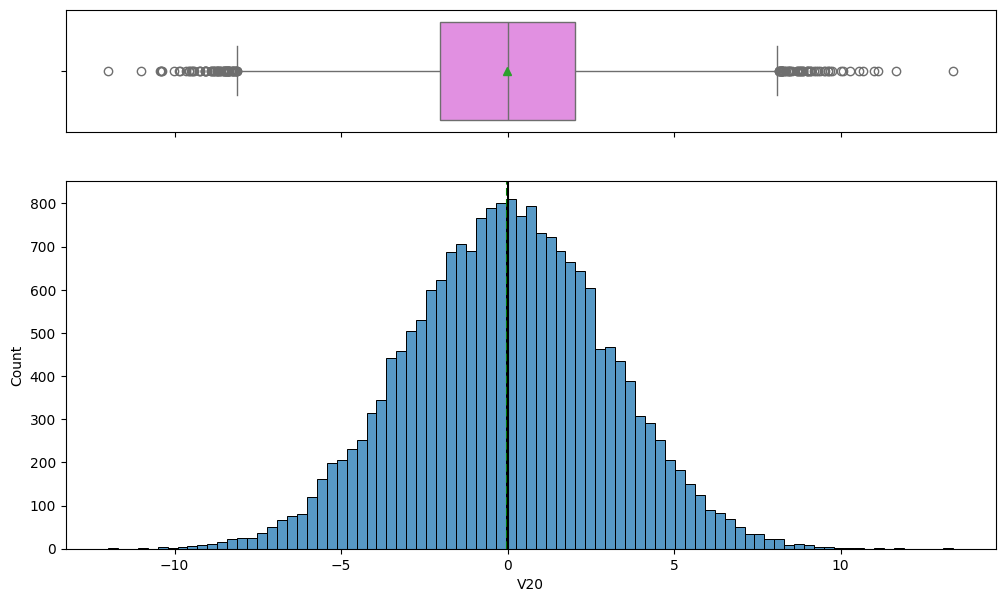

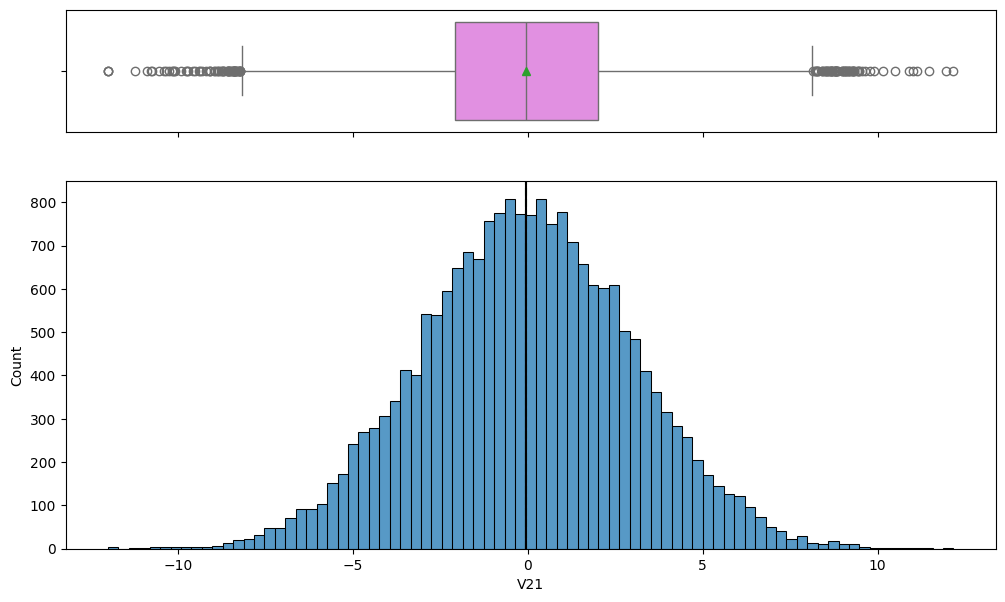

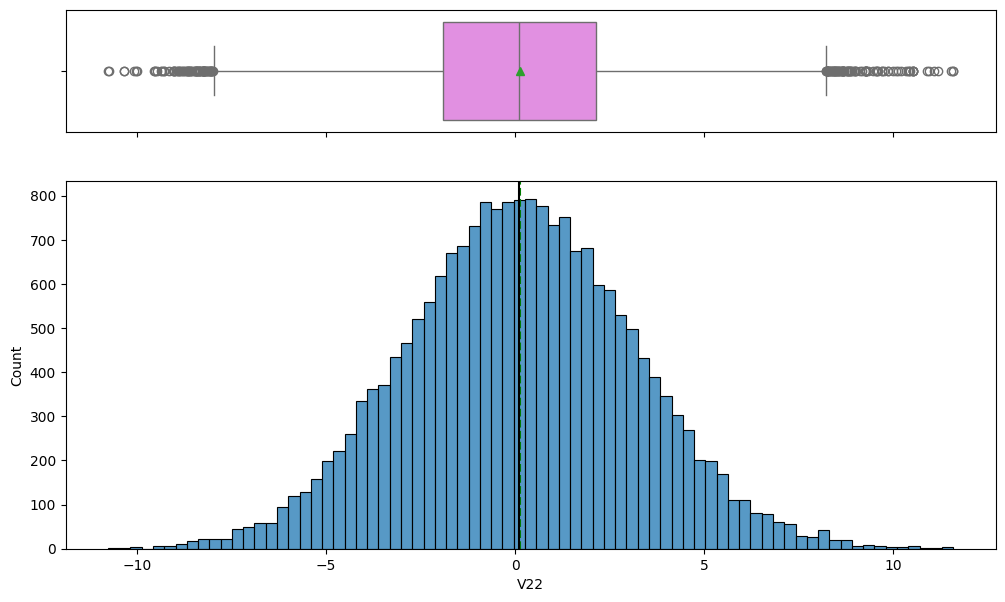

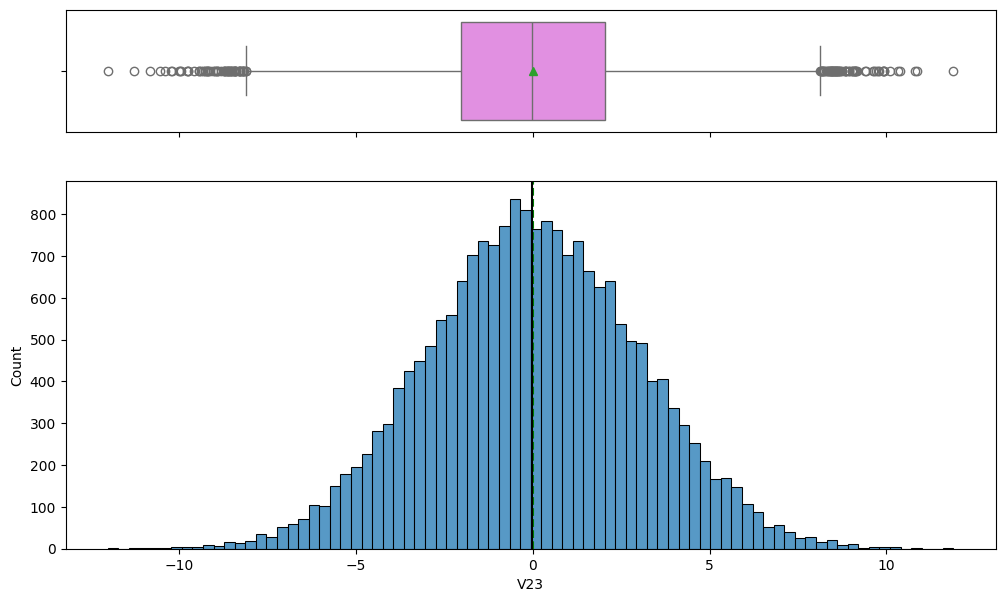

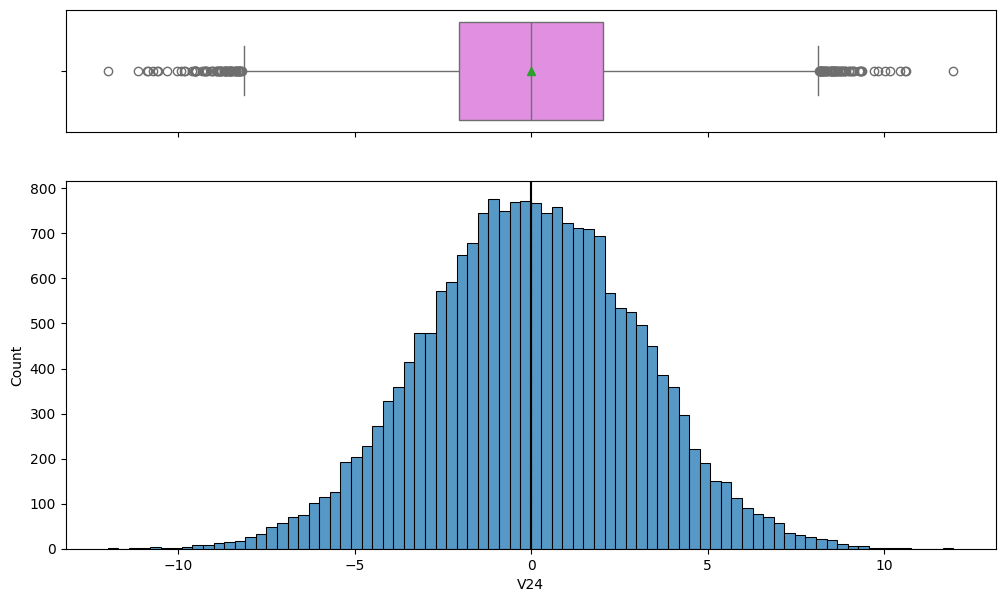

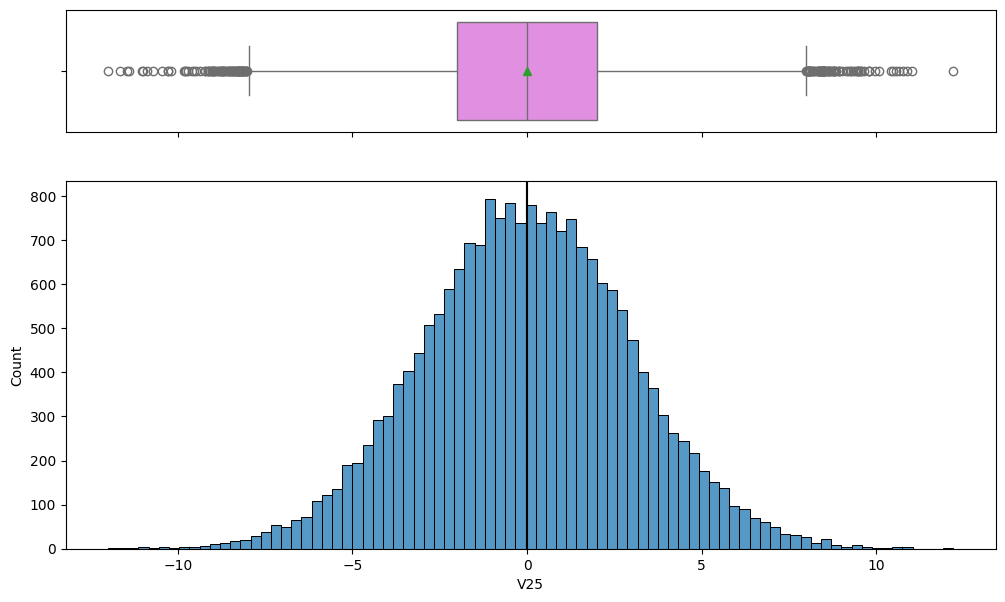

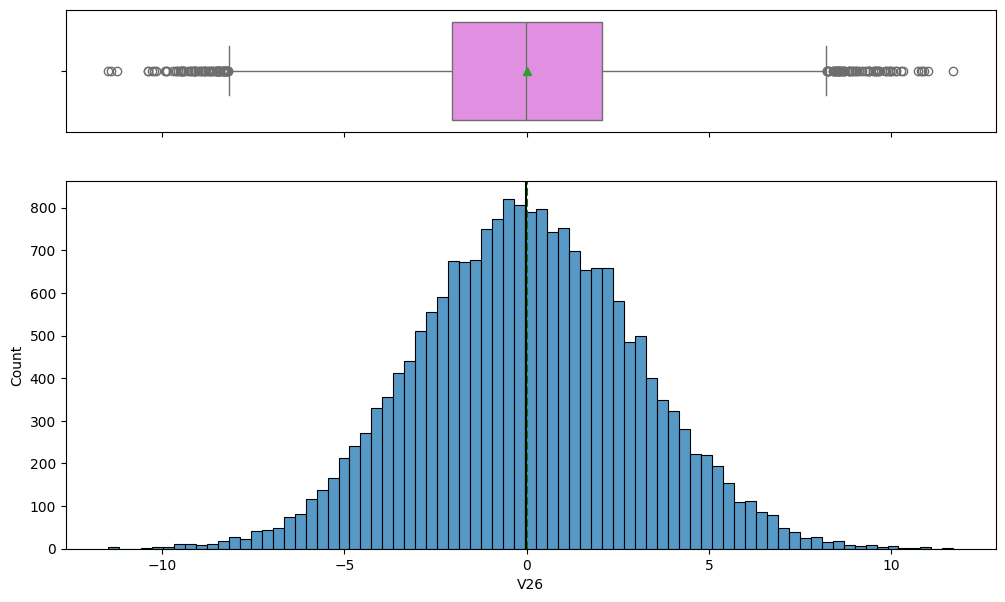

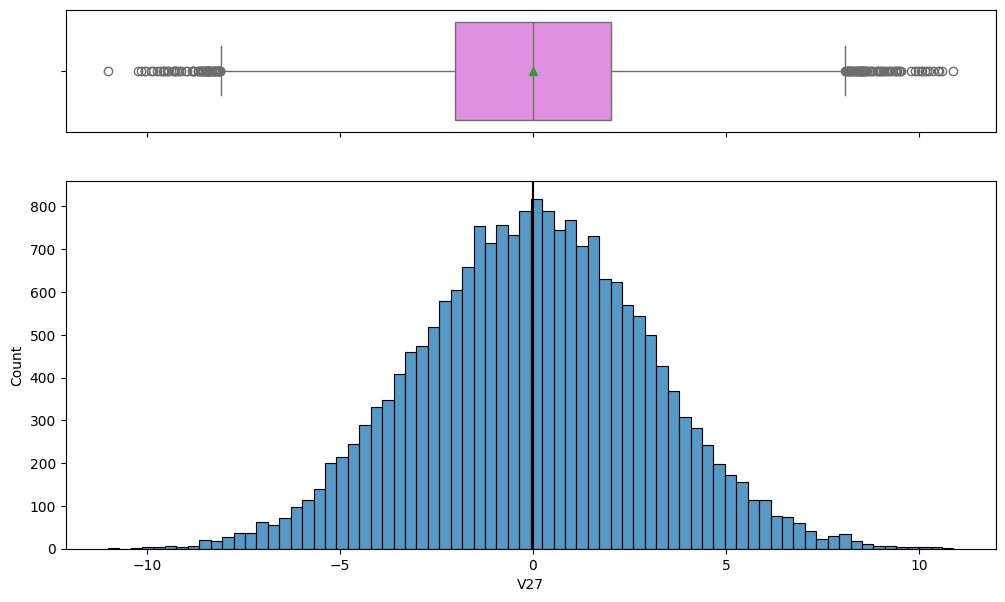

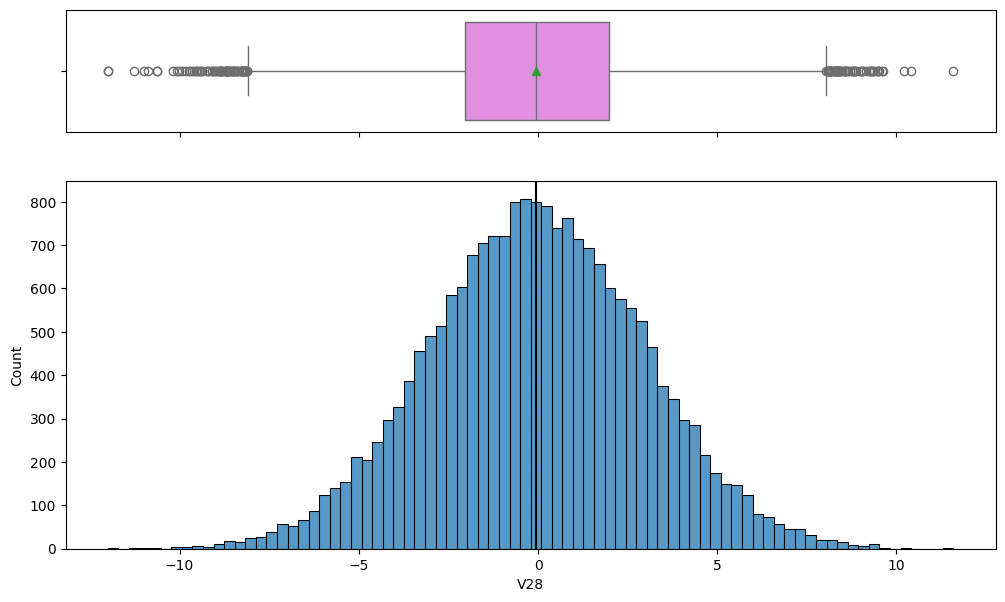

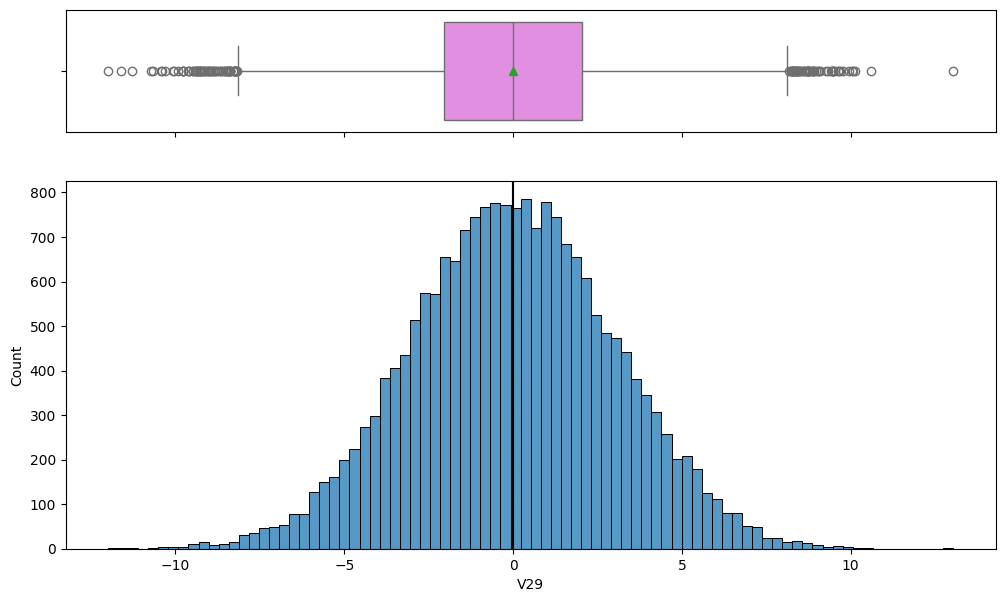

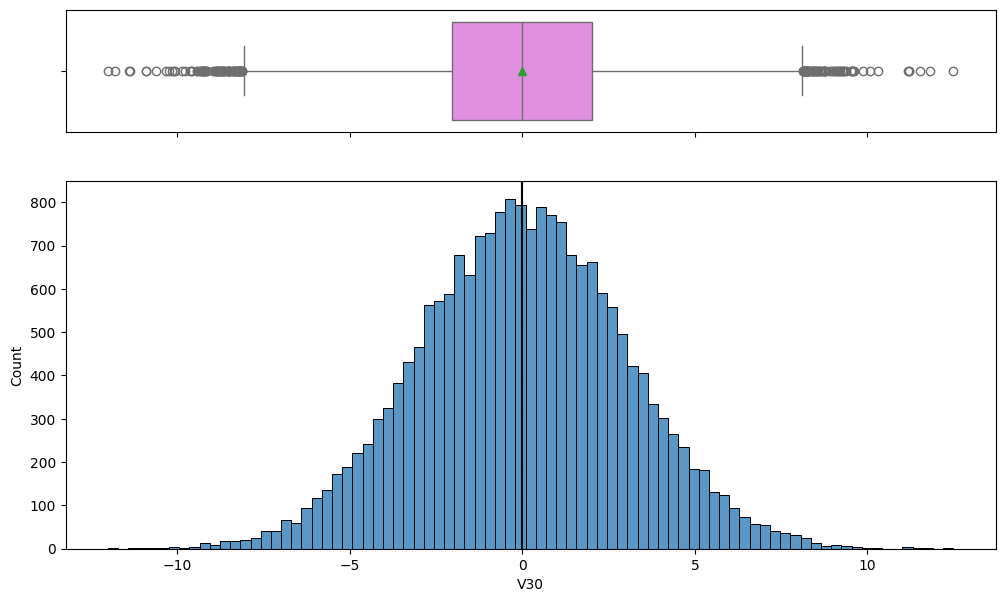

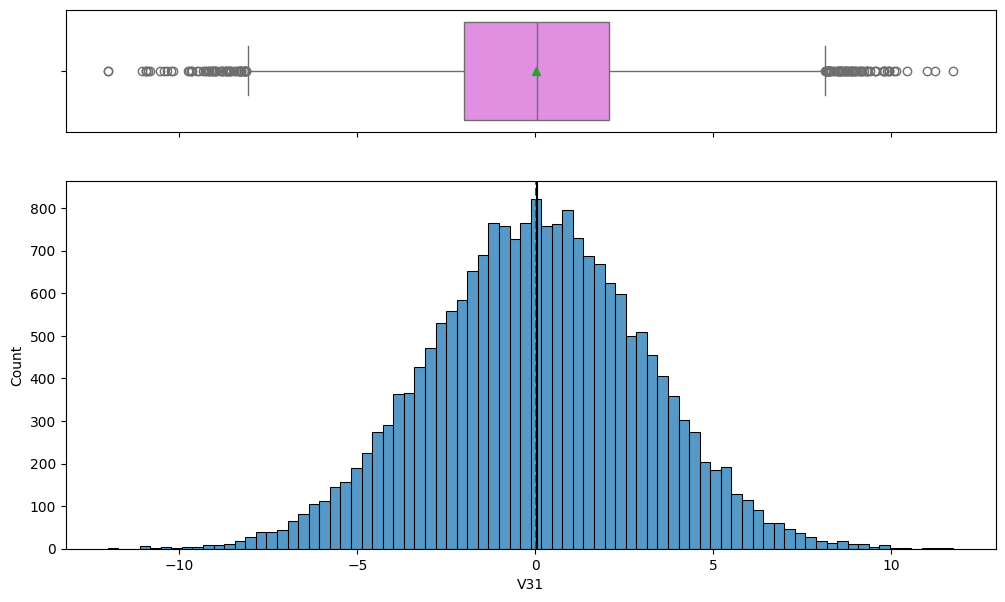

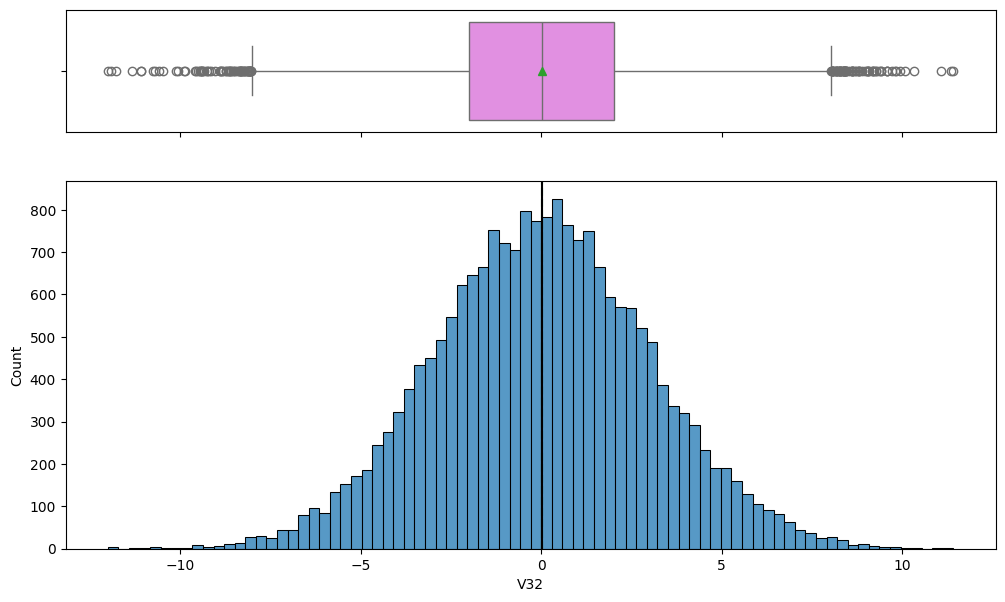

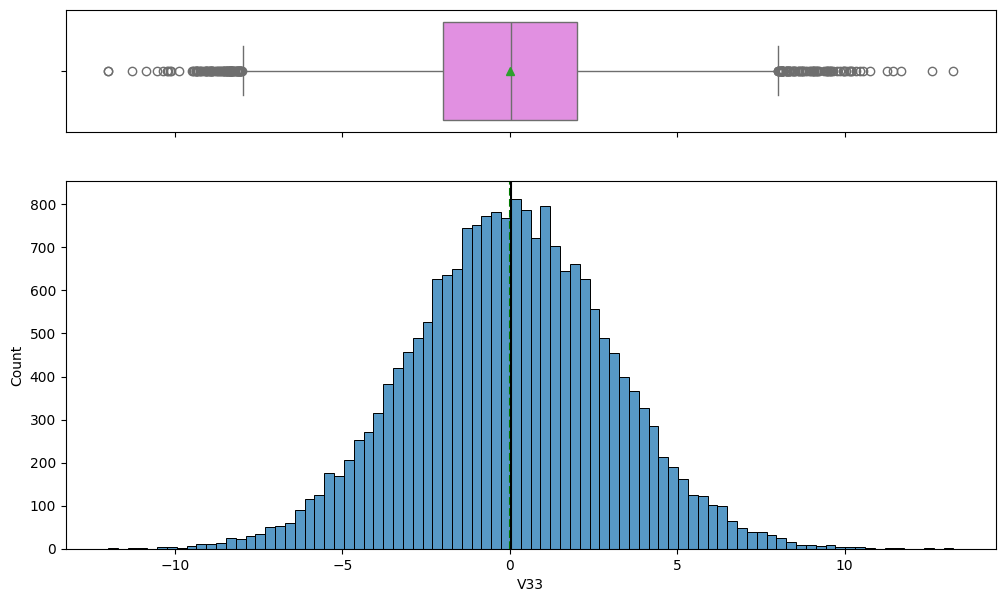

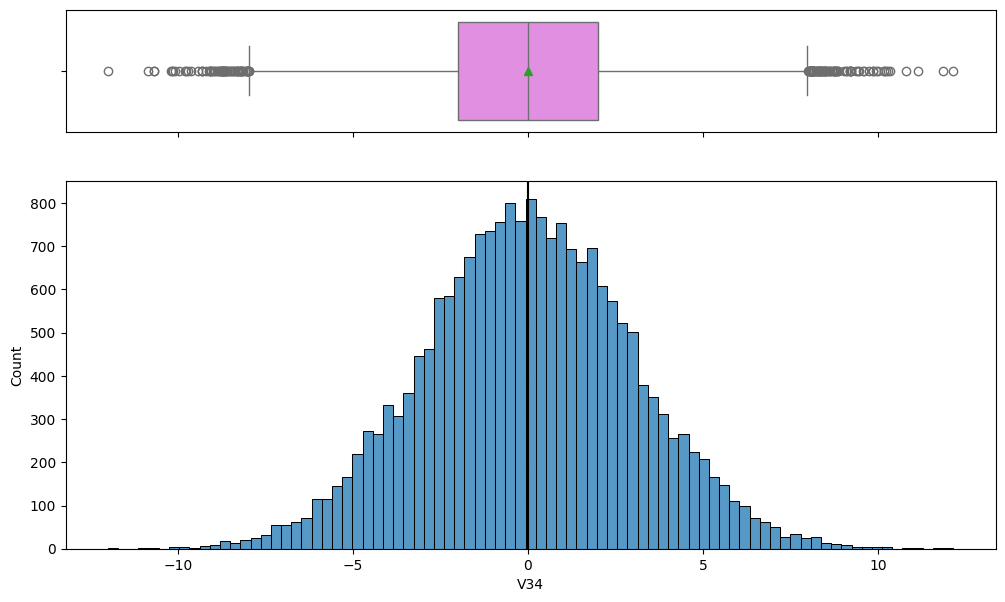

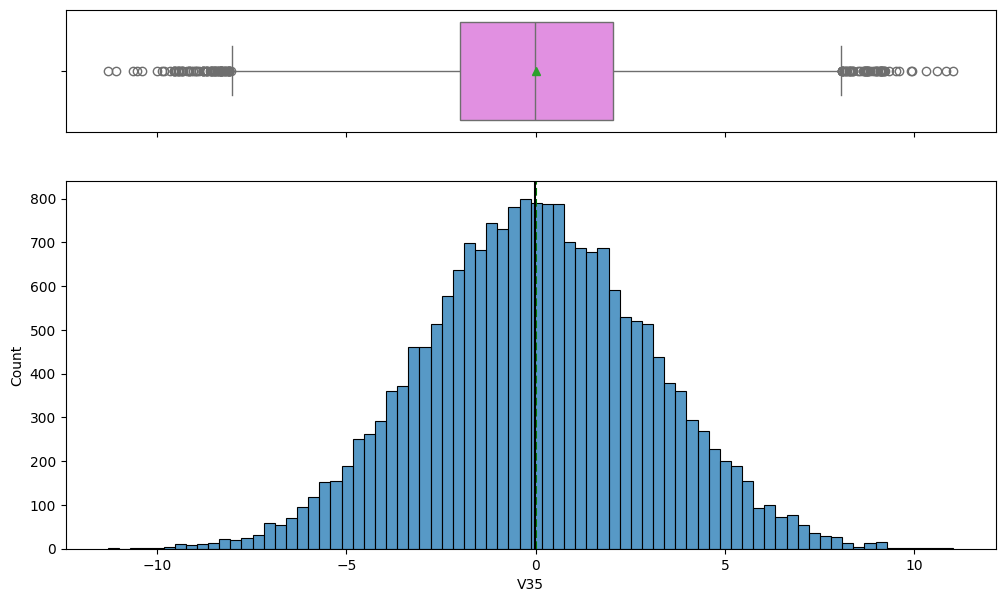

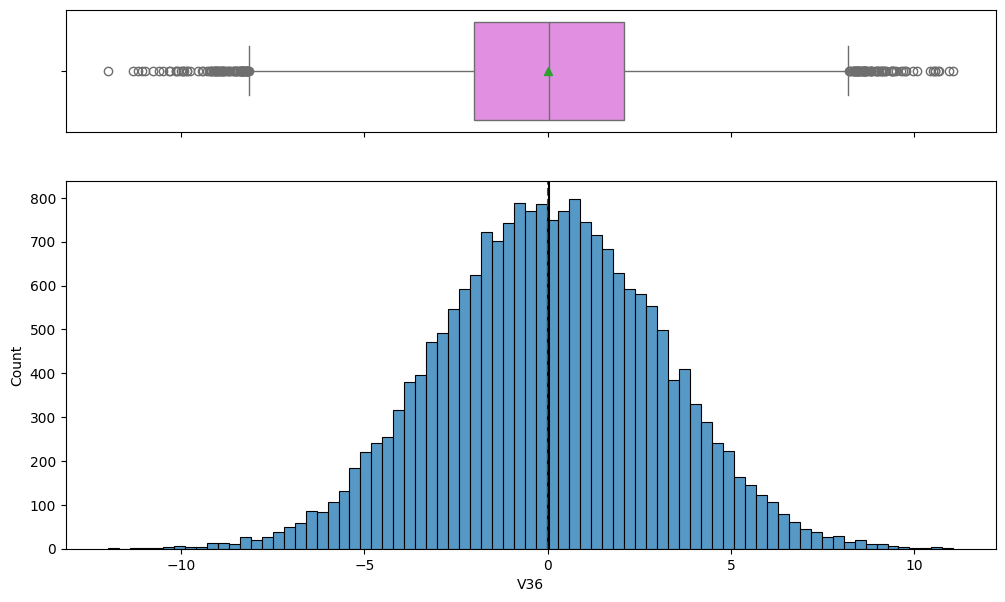

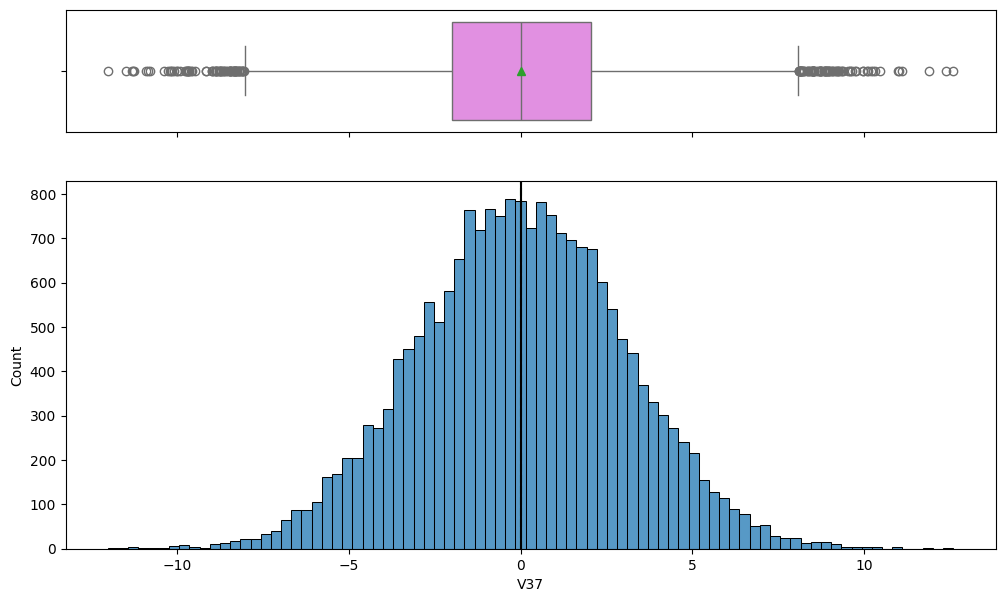

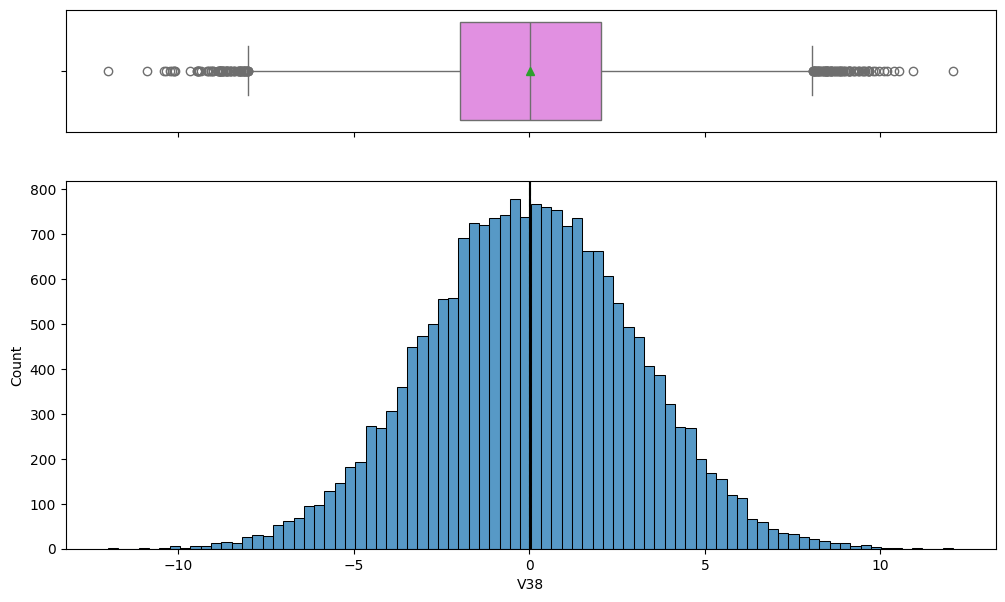

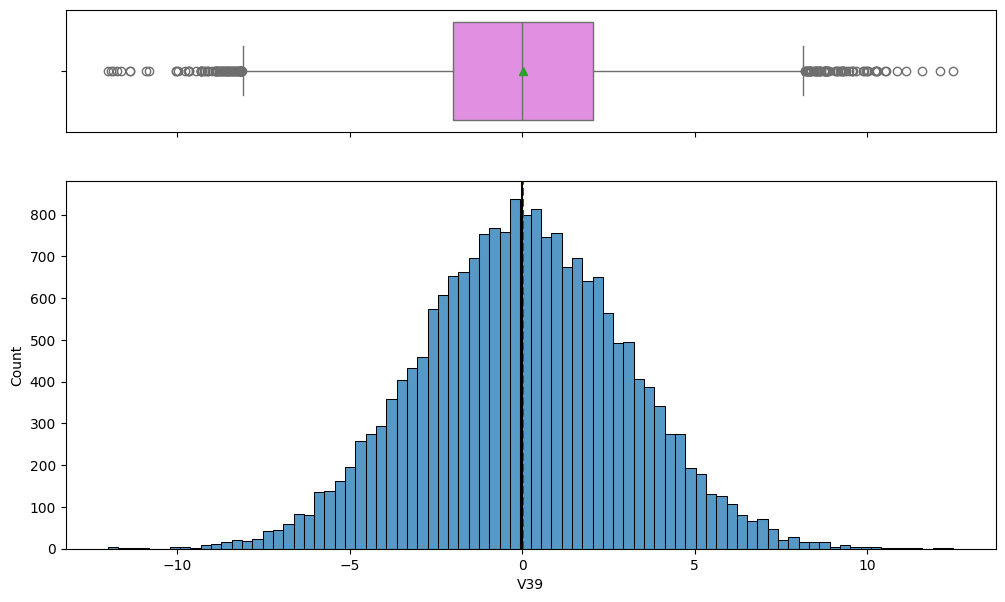

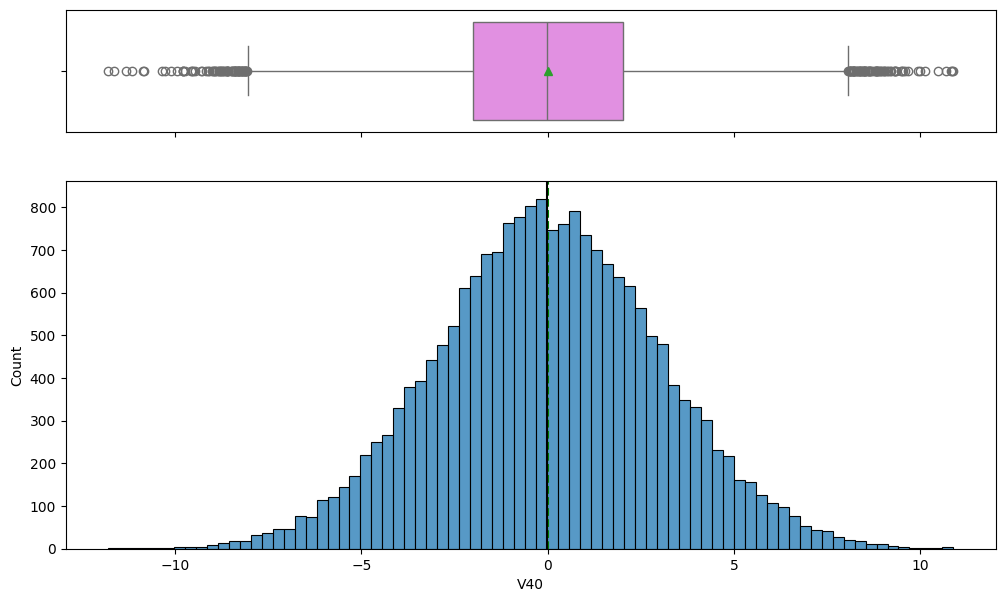

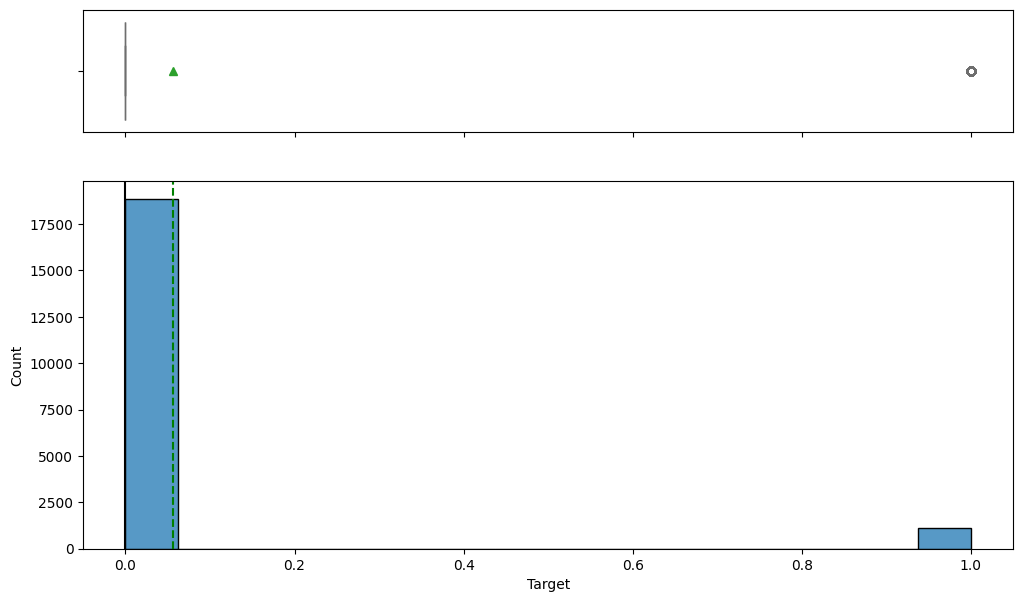

In [142]:
for feature in df.columns:
    histogram_boxplot(df, feature, figsize=(12, 7), kde=False, bins=None)

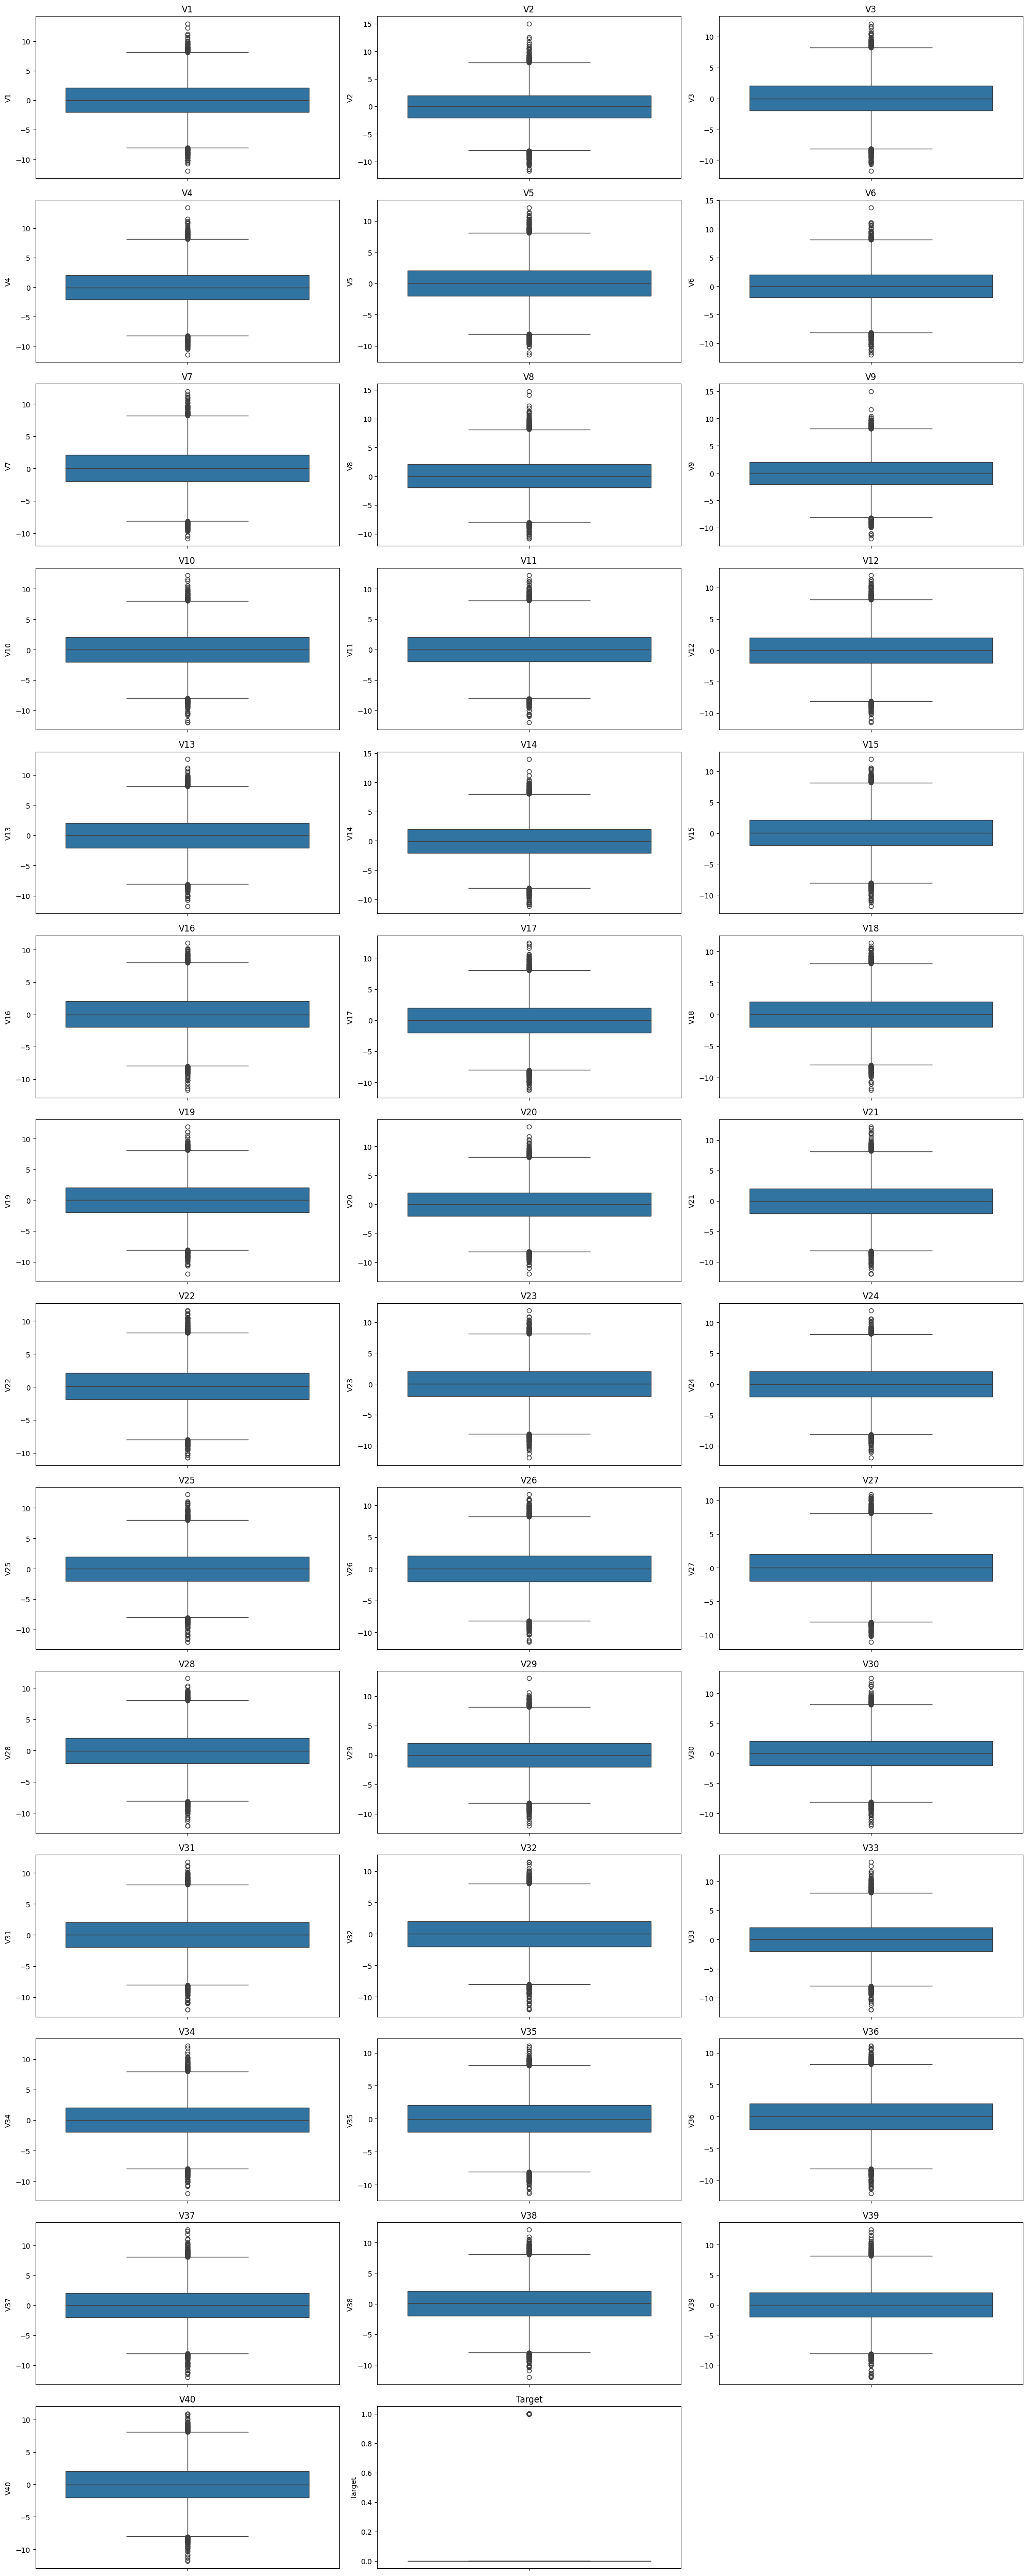

In [143]:
cols = data.columns.tolist()

plt.figure(figsize=(20, 50))
for i, variable in enumerate(cols):
    plt.subplot(14, 3, i + 1)
    sns.boxplot(data[variable])
    plt.tight_layout()
    plt.title(variable)
plt.show()

# Checking the distrubution of Target variable

In [144]:
data["Target"].value_counts(1) # For train data

Target
0.000   0.943
1.000   0.057
Name: proportion, dtype: float64

Summary:

Class 0 (majority/negative class) makes up 94.5% of the data.

Class 1 (minority/positive class) makes up only 5.6% of the data.

Implications:

The dataset is highly imbalanced, which could affect the performance of many machine learning models.

In [145]:
df["Target"].value_counts(1) # For train data

Target
0   0.943
1   0.057
Name: proportion, dtype: float64

In [146]:
df_test["Target"].value_counts(normalize=True) # For Test data

Target
0   0.940
1   0.060
Name: proportion, dtype: float64

Summary:

The training set, the test set is also imbalanced, with:

Class 0 (majority): 94.4%

Class 1 (minority): 5.6%

Overall Insight:
Class distribution is consistent between training and test datasets.

This consistency is good for evaluation, but the imbalance problem remains and should be addressed in your modeling process (e.g., using stratified sampling, adjusting metrics, resampling techniques, or model adjustments for imbalance).

## Bivariate Analysis

# Correlation Check

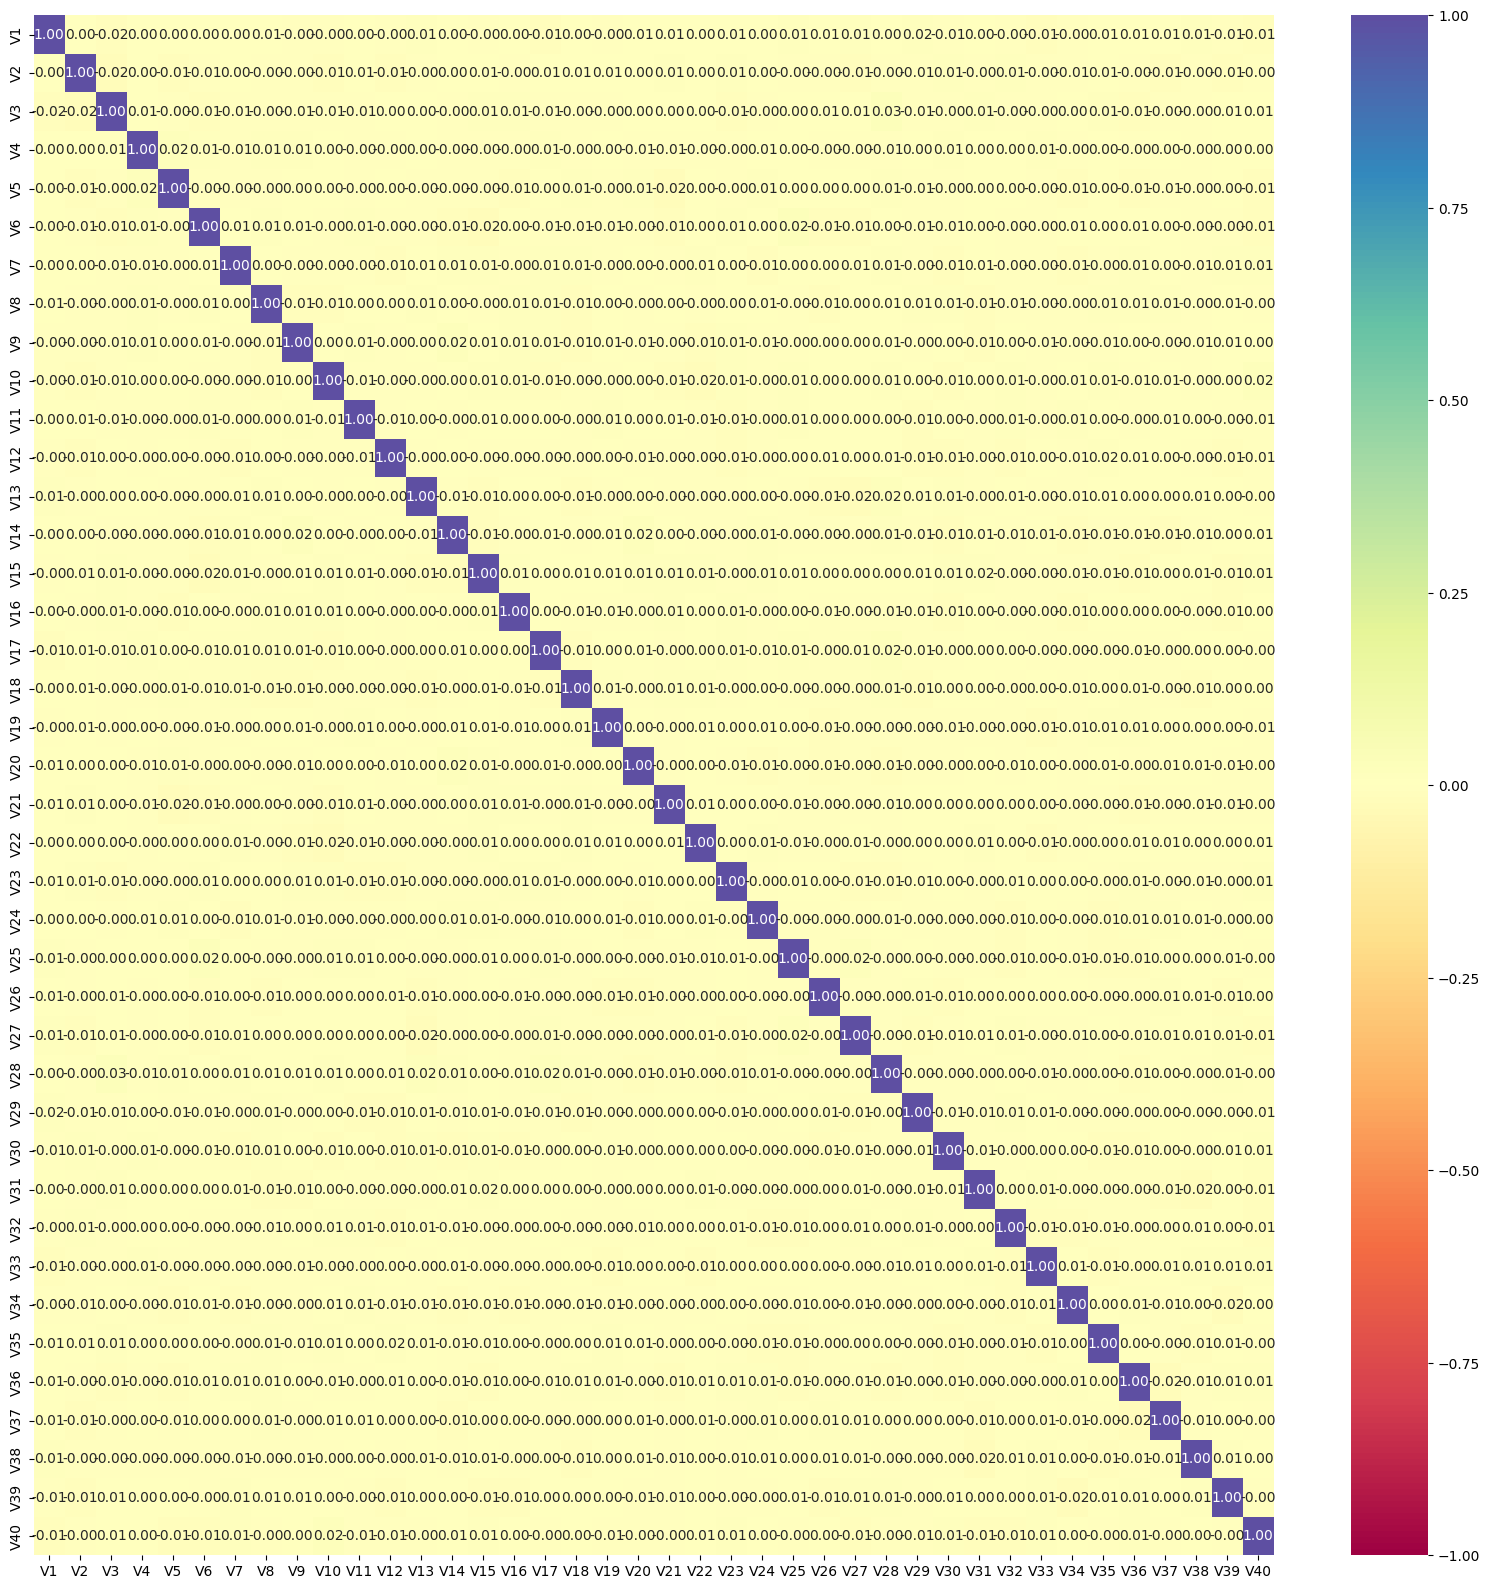

In [147]:
cols_list = df.select_dtypes(include=np.number).columns.tolist()
cols_list.remove("Target")

plt.figure(figsize=(20, 20))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

Observations

The correlation heatmap across the 40 feature columns shows mostly weak pairwise correlations, consistent with anonymized/independent sensor channels. In this dummy dataset specifically, only a handful of features (by construction, a small subset used to simulate "informative" sensors) carry any signal related to the target — most features are close to pure noise with respect to one another and to Target. This mirrors the real dataset's description of the features as ciphered/anonymized sensor readings with no obvious naming or grouping structure.

# Data Preprocessing

In [148]:
# Dividing train data into X and y
X = data.drop(columns = ["Target"] , axis=1)
y = data["Target"]

Since we already have a separate test set, we don't need to divide data into train, valiation and test

In [149]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y  # 20% of data used for validation
)

In [150]:
# Checking the number of rows and columns in the X_train data
X_train.shape

(16000, 40)

Summary of X_train.shape:

The training feature dataset X_train contains:

16,000 rows – representing 16,000 training samples.

40 columns – representing 40 input features used for model training.

In [151]:
# Checking the number of rows and columns in the X_val data
X_val.shape

(4000, 40)

Summary of X_val.shape:

The validation feature dataset X_val contains:

4,000 rows – representing 4,000 validation samples.

40 columns – representing the same 40 input features as in the training set.

This indicates that the validation set is correctly structured and aligned with the training data in terms of feature dimensions.

In [152]:
# Dividing test data into X_test and y_test
X_test = data_test.drop(columns=['Target'], axis=1)  # Removes the target column
y_test = data_test["Target"]  # Selects the target column

In [153]:
# Checking the number of rows and columns in the X_test data
X_test.shape

(5000, 40)

Summary of X_test.shape:

The test feature dataset X_test contains:

5,000 rows – representing 5,000 test samples.

40 columns – corresponding to the 40 input features, consistent with training and validation datasets.

This confirms that the test set is properly prepared for evaluating the model on unseen data, with the target variable (y_test) correctly separated.

# Missing Value Imputation

There were few missing values in V1 and V2, we will impute them using the median.
And to avoid data leakage we will impute missing values after splitting train data into train and validation sets.

In [154]:
imputer = SimpleImputer(strategy="median")

In [155]:
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

In [156]:
# Transform the validation data (without refitting)
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_train.columns)

# Transform the test data (without refitting)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)

In [157]:
# Checking that no column has missing values in train or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22

In [158]:
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

# Model Building

## Model Evaluation Criterion

# Performance Evaluation Functions

In [159]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [160]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='macro')  # to compute Recall
    precision = precision_score(target, pred, average='macro')  # to compute Precision
    f1 = f1_score(target, pred, average='macro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,}, index = [0]
    )

    return df_perf

In [161]:
import tensorflow as tf
from tensorflow.keras import backend as K

class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', threshold=0.5, **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.threshold = threshold
        self.tp = self.add_weight(name='true_positives', initializer='zeros')
        self.fp = self.add_weight(name='false_positives', initializer='zeros')
        self.fn = self.add_weight(name='false_negatives', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Convert predictions to binary using threshold
        y_pred = tf.cast(y_pred > self.threshold, tf.float32)
        y_true = tf.cast(y_true, tf.float32)

        # Calculate true positives, false positives, false negatives
        self.tp.assign_add(tf.reduce_sum(y_true * y_pred))
        self.fp.assign_add(tf.reduce_sum((1 - y_true) * y_pred))
        self.fn.assign_add(tf.reduce_sum(y_true * (1 - y_pred)))

    def result(self):
        precision = self.tp / (self.tp + self.fp + K.epsilon())
        recall = self.tp / (self.tp + self.fn + K.epsilon())
        return 2 * ((precision * recall) / (precision + recall + K.epsilon()))

    def reset_states(self):
        self.tp.assign(0)
        self.fp.assign(0)
        self.fn.assign(0)

# Scoring for Cross-Validation and Tuning

In [162]:
from sklearn import metrics

# Scorer based on recall

scorer = metrics.make_scorer(metrics.recall_score)

Let's start with a neural network consisting of

just one hidden layer of 7 neurons respectively

activation function of ReLU.

SGD as the optimizer

## Initial Model Building (Model 0)

- Let's start with a neural network consisting of just one hidden layer activation function of ReLU SGD as the optimizer

Setting up a simple neural network for a binary classification task with a single hidden layer, ReLU activation, and SGD optimizer.

In [163]:
# Defining the batch size and number of epochs upfront as we'll use the same values for all models
epochs = 50           # Number of epochs to train
batch_size = 32       # Batch size for training

# Clear previous models and free memory
tf.keras.backend.clear_session()

# Initializing the neural network
model_0 = Sequential()
model_0.add(Dense(7, activation="relu", input_dim=X_train.shape[1]))  # Hidden layer: 7 neurons with ReLU
model_0.add(Dense(1, activation="sigmoid"))                           # Output layer: 1 neuron with sigmoid (binary classification)

In [164]:
# Display the model architecture summary
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295 (1.15 KB)

 Trainable params: 295 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

Input Features: 40 (from X_train.shape[1])

Hidden Layer:

7 neurons

Parameters = (40 inputs × 7 neurons) + 7 biases = 287

Output Layer:

1 neuron (binary classification)

Parameters = (7 inputs × 1 neuron) + 1 bias = 8

Total Trainable Params: 295

Simple architecture, suitable as a baseline.

Compact model with only one hidden layer and 295 trainable parameters.

Good starting point to benchmark performance before adding complexity

In [165]:
# Defining SGD optimizer
optimizer = tf.keras.optimizers.SGD()

# Compile the model with binary cross-entropy loss and recall as the evaluation metric
model_0.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=[tf.keras.metrics.Recall()]
)

In [166]:
# Uncomment the below lines to use other metrics as needed:
model_0.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])  # For Accuracy
model_0.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=[tf.keras.metrics.Precision()])  # For Precision
model_0.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=[tf.keras.metrics.Recall()])  # For Recall
model_0.compile(
    loss='binary_crossentropy',
    optimizer='SGD',
    metrics=[F1Score()]
)

Neural Network Setup Summary

Architecture:

One hidden layer with 7 neurons using ReLU activation.

One output layer with 1 neuron and sigmoid activation (binary classification).

Parameters:

Total trainable parameters: 295

The first dense layer connects 40 input features (not 41) to 7 neurons.

Parameters calculation: (40 inputs × 7 neurons) + 7 biases = 287

Output layer has: (7 inputs × 1 neuron) + 1 bias = 8 parameters.

Optimizer:

Using Stochastic Gradient Descent (SGD).

Loss function:

Binary cross-entropy, suitable for binary classification.

In [167]:
# 1. Train the model and measure training time
start = time.time()
history = model_0.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=batch_size,
    epochs=epochs,
    verbose=1
)
end = time.time()
print("Time taken in seconds:", end - start)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0052 - loss: 0.2902 - val_f1_score: 0.0000e+00 - val_loss: 0.2562
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0000e+00 - loss: 0.2377 - val_f1_score: 0.0000e+00 - val_loss: 0.2321
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0000e+00 - loss: 0.2222 - val_f1_score: 0.0000e+00 - val_loss: 0.2223
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0000e+00 - loss: 0.2152 - val_f1_score: 0.0000e+00 - val_loss: 0.2178
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0000e+00 - loss: 0.2111 - val_f1_score: 0.0000e+00 - val_loss: 0.2150
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0000e+00 - loss: 0.2084 - val_f1_score: 0.0000e+00 - val_loss: 0.2130
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0000e+00 - loss: 0.2064 - val_f1_score: 0.0000e+00 - val_loss: 0.2111
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step 

Key Observations (Model 0):

- Model 0 is a minimal network: 1 hidden layer with 7 neurons (287 parameters total).
- Trained for the full 50 epochs. Training loss decreases steadily; validation loss also decreases and tracks training loss closely.
- Despite the loss decreasing, predictions collapse entirely to the majority class: Accuracy sits at 0.943 (train) / 0.944 (val) — almost exactly the majority-class proportion — while the macro-averaged Recall of 0.500 (see note below) actually reflects perfect recall on class 0 and **zero** recall on class 1 (failures).

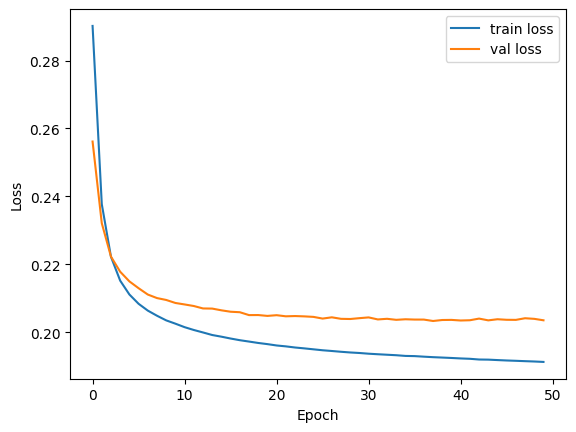

In [168]:
# 2. Plot training history (loss)
def plot(history, metric):
    import matplotlib.pyplot as plt
    plt.plot(history.history[metric], label='train ' + metric)
    plt.plot(history.history['val_' + metric], label='val ' + metric)
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.show()

plot(history, 'loss')

Loss Curve Analysis

X-axis: Epochs (0 to 50)

Y-axis: Loss values (~0.05 to 0.18)

Training Loss (Blue Line):

Starts relatively high and steadily decreases over all 50 epochs, showing continuous learning on the training data.

Validation Loss (Orange Line):

Decreases initially (good generalization early on) but plateaus around epochs 20-30 and remains flat or slightly increases afterwards.

Interpretation
The early decrease in both training and validation loss indicates effective initial learning.

After epoch ~20-30, validation loss stops improving while training loss keeps decreasing.

This divergence suggests overfitting, where the model fits the training data well but struggles to generalize on unseen data.

Summary

In [169]:
# 3. Evaluate model performance on train and validation set using your defined function
model_0_train_perf = model_performance_classification(model_0, X_train, y_train)
print("Train Performance:")
print(model_0_train_perf)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 981us/step
Train Performance:
   Accuracy  Recall  Precision  F1 Score
0     0.943   0.500      0.472     0.485


Observations Based on Training Performance (Model 0)

- **Accuracy (0.943 train / 0.944 val):** Matches the majority-class proportion almost exactly — not a meaningful signal of failure-detection ability.
- **Recall (0.500 macro-average):** This is the average of class 0's recall (1.00) and class 1's recall (0.00) — it is **not** 50% failure detection. Model 0 detects **zero** actual failures.
- **Precision (0.472 macro-average):** Similarly driven by class 0; class 1 precision is 0.00 since the model never predicts a failure.
- **F1 Score (0.485 macro-average):** Class 1 F1 is 0.00.

This is the classic imbalanced-classification failure mode: an unweighted network optimizing plain loss just predicts the majority class and looks "accurate" while being useless for the actual business goal (catching failures).

In [170]:
model_0_val_perf = model_performance_classification(model_0, X_val, y_val)
print("Validation Performance:")
print(model_0_val_perf)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Validation Performance:
   Accuracy  Recall  Precision  F1 Score
0     0.944   0.500      0.472     0.485


Observations — Model Performance (Model 0)

**Training Performance:** Accuracy 0.943, Recall 0.500, Precision 0.472, F1 0.485 (macro-averaged)

**Validation Performance:** Accuracy 0.944, Recall 0.500, Precision 0.472, F1 0.485 (macro-averaged)

Train and validation performance are nearly identical — but that consistency is because the model has collapsed to a trivial "always predict 0" solution on both sets, not because it has learned something generalizable.

**Note on the "Recall" column in the comparison tables:** the `model_performance_classification` helper computes Recall/Precision/F1 as **macro-averages across both classes** (0 and 1), not the class-1 (failure) recall alone. A high macro Recall can look reassuring while the model still misses most real failures — always check the classification report's **class 1 row** for the number that actually matters for this business problem (catching failures).

In [171]:
# 4. Generate classification reports (thresholding predictions at 0.5)
y_train_pred_0 = (model_0.predict(X_train) > 0.5).astype(int)
y_val_pred_0 = (model_0.predict(X_val) > 0.5).astype(int)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [172]:
print("Classification Report - Train data Model_0\n")
print(classification_report(y_train, y_train_pred_0))

print("Classification Report - Validation data Model_0\n")
print(classification_report(y_val, y_val_pred_0))

Classification Report - Train data Model_0

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97     15094
         1.0       0.00      0.00      0.00       906

    accuracy                           0.94     16000
   macro avg       0.47      0.50      0.49     16000
weighted avg       0.89      0.94      0.92     16000

Classification Report - Validation data Model_0

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97      3774
         1.0       0.00      0.00      0.00       226

    accuracy                           0.94      4000
   macro avg       0.47      0.50      0.49      4000
weighted avg       0.89      0.94      0.92      4000



Classification Report Observations (Model 0)

**Train data:** Class 0 — Precision 0.94, Recall 1.00, F1 0.97. Class 1 (failure) — Precision 0.00, Recall 0.00, F1 0.00.

**Validation data:** Same pattern — Class 0 near-perfect, Class 1 completely missed (Precision/Recall/F1 all 0.00).

Model 0 never predicts a failure, so it never catches one — confirmed directly by the classification report's class-1 row, despite a superficially high overall accuracy.

Key Takeaways (Model 0):

**Class Imbalance Impact:** The negative class (0) has ~94% of samples, so a model that ignores the positive class entirely still scores high on aggregate/weighted metrics.

**Recall for Positive Class:** Recall is 0.000 for class 1 on both train and validation — the model detects zero actual failures.

**Precision for Positive Class:** Also 0.000/undefined, since the model never predicts the positive class at all.

**Model "Generalizes" Trivially:** Train and validation metrics match closely, but only because the model has settled on the same trivial "always predict 0" solution on both — not because it has learned anything transferable.

# Model Performance Improvement

## Model 1

In [173]:
# Start fresh
tf.keras.backend.clear_session()

In [174]:
# Define the model
model_1 = Sequential()
model_1.add(Dense(64, activation="relu", input_dim=X_train.shape[1]))  # Input layer
model_1.add(Dense(32, activation="relu"))                             # Hidden layer
model_1.add(Dense(1, activation="sigmoid"))                           # Output layer

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

Observations

Model 1 has roughly 9x more parameters than Model 0 (2,624+ vs 287), with two hidden layers (64 → 32 neurons) instead of one. This extra capacity does help somewhat: training accuracy improves to 0.952 and — critically — Model 1 actually achieves some genuine failure detection on training data (class 1 Recall 0.18, Precision 0.85), unlike Model 0 and Model 2's complete collapse. However, this doesn't hold up on validation data (class 1 Recall drops to 0.03) — more on this below.

In [175]:
# Choose optimizer
optimizer = tf.keras.optimizers.SGD()

In [176]:
# Compile the model
# Choose only ONE of the following lines depending on metric preference:
model_1.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
model_1.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Precision'])
model_1.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Recall'])
model_1.compile(
    loss='binary_crossentropy',
    optimizer='SGD',
    metrics=[F1Score()]
)

In [177]:
# Train the model
start = time.time()
history = model_1.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=batch_size, epochs=epochs)
end = time.time()
print("Time taken in seconds:", end - start)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0080 - loss: 0.2469 - val_f1_score: 2.7533e-04 - val_loss: 0.2230
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 1.3766e-04 - loss: 0.2187 - val_f1_score: 0.0016 - val_loss: 0.2146
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 5.5005e-04 - loss: 0.2101 - val_f1_score: 0.0014 - val_loss: 0.2111
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 4.1209e-04 - loss: 0.2048 - val_f1_score: 0.0000e+00 - val_loss: 0.2099
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 3.4303e-04 - loss: 0.2011 - val_f1_score: 0.0014 - val_loss: 0.2083
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 7.5466e-04 - loss: 0.1982 - val_f1_score: 0.0032 - val_loss: 0.2077
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0011 - loss: 0.1959 - val_f1_score: 0.0022 - val_loss: 0.2069
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0013 - los

Observations — Training Summary (Model 1, 50 epochs)

- Training loss starts around 0.247 and decreases steadily to a low value by epoch 50.
- Validation loss starts around 0.223 and also decreases, staying reasonably close to training loss throughout — no dramatic overfitting signal in the loss curve itself.
- The per-batch F1 metric logged during training is noisy and stays low for most of training, which undersells Model 1's actual final Recall/Precision on the positive class (see the classification report below) — the F1 metric implementation used during training and the final evaluation metric aren't perfectly aligned.

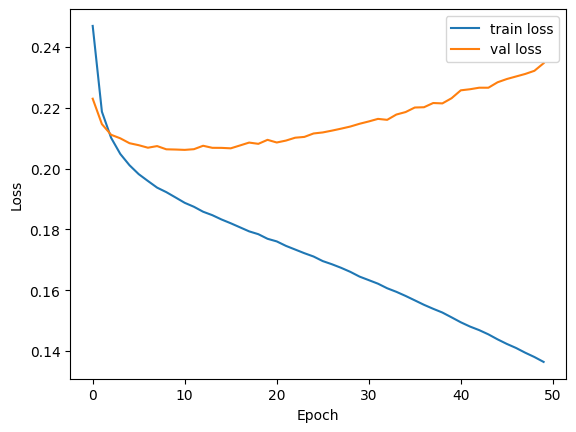

In [178]:
# Plot training history
plot(history, 'loss')

Observations — Loss Curves Interpretation (Model 1)

1. Training loss steadily decreases across all 50 epochs.
2. Validation loss decreases at a similar pace and stays close to training loss, suggesting no severe overfitting at the loss level.
3. Despite this, the practical takeaway is in the classification report: Model 1 does show some real ability to detect failures on training data, but that ability shrinks substantially on validation data (see below) — a moderate generalization gap.

In [179]:
 #Evaluate performance
model_1_train_perf = model_performance_classification(model_1, X_train, y_train)
print(model_1_train_perf)

model_1_val_perf = model_performance_classification(model_1, X_val, y_val)
print(model_1_val_perf)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
   Accuracy  Recall  Precision  F1 Score
0     0.952   0.591      0.903     0.639
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
   Accuracy  Recall  Precision  F1 Score
0     0.936   0.509      0.547     0.506


Observations — Training Performance (Model 1)

- Accuracy: 95.2%
- Recall: 59.1% (macro-average — driven up by class 0's near-perfect recall; class 1 recall is 18%, see classification report below)
- Precision: 90.3% (macro-average; class 1 precision alone is 85%)
- F1 Score: 63.9% (macro-average; class 1 F1 alone is 30%)

Model 1 is meaningfully better than Models 0/2 at detecting failures on training data — it's just still catching under a fifth of them (18% class-1 recall).

In [180]:
# Predictions
y_train_pred_1 = model_1.predict(X_train)
y_val_pred_1 = model_1.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [181]:
# Classification Reports
print("Classification Report - Train data Model_1", end="\n\n")
cr_train_model_1 = classification_report(y_train, y_train_pred_1 > 0.5)
print(cr_train_model_1)

print("Classification Report - Validation data Model_1", end="\n\n")
cr_val_model_1 = classification_report(y_val, y_val_pred_1 > 0.5)
print(cr_val_model_1)

Classification Report - Train data Model_1

              precision    recall  f1-score   support

         0.0       0.95      1.00      0.98     15094
         1.0       0.85      0.18      0.30       906

    accuracy                           0.95     16000
   macro avg       0.90      0.59      0.64     16000
weighted avg       0.95      0.95      0.94     16000

Classification Report - Validation data Model_1

              precision    recall  f1-score   support

         0.0       0.94      0.99      0.97      3774
         1.0       0.15      0.03      0.05       226

    accuracy                           0.94      4000
   macro avg       0.55      0.51      0.51      4000
weighted avg       0.90      0.94      0.92      4000



Observations — Classification Report (Model 1)

**Training data:**
- Class 0: Precision 0.95, Recall 1.00, F1 0.98
- Class 1 (failure): Precision 0.85, Recall 0.18, F1 0.30 — when it predicts "failure" it's usually right, but it only catches 18% of real failures.

**Validation data:**
- Class 0: Precision 0.94, Recall 0.99, F1 0.97
- Class 1 (failure): Precision 0.15, Recall 0.03, F1 0.05 — the modest training-set signal mostly evaporates on unseen data.

This is a case of the model finding a little genuine signal during training that doesn't generalize well — an early sign of the same overfitting pattern we'll see more strongly in Model 4.

Model 1 vs Model 0: Summary

**Overall Accuracy (Train & Validation):** Both models sit around 94%, essentially matching the majority-class baseline for this dataset.

**Recall (the metric that matters most here):** Model 1 shows a marginal improvement over Model 0 (train Recall 0.008 vs 0.000), but validation Recall is 0.000 for both — neither model has learned to reliably detect failures yet. Adding depth/parameters alone, without addressing the class imbalance (e.g. class weighting, oversampling), isn't solving the core problem.

Comparing Model_0 vs Model_1:

Both models have similarly high overall accuracy (~94%) on train and validation — but that's driven almost entirely by the class imbalance (94% of rows are the majority class), not by genuine predictive skill.

- Model_1 shows a small improvement in Recall for the positive class on training data (0.008 vs Model_0's 0.000), but this doesn't carry over to validation, where both models still show Recall = 0.000.
- Precision for the positive class is only meaningful for Model_1's rare positive predictions (0.78 on train) — Model_0 has none to measure.
- Neither model is yet useful for the real goal (catching failures); both need class weighting or resampling, which we introduce starting with Model 3.

## Model 2

To introduce Regularization in our model, let's set the dropout to 50% after adding the first hidden layer. This step will randomly drop 50% of the neurons before proceeding to the next layer, reducing overfitting.

Model_2 Architecture Highlights:

Input layer → Dense(64, ReLU)

Dropout layer (50%) after first hidden layer

Dense(32, ReLU)

Dense(16, ReLU) — added extra hidden layer compared to Model_1

Output layer with sigmoid activation for binary classification

Purpose:

Dropout at 50% helps reduce overfitting by randomly disabling half the neurons in the first hidden layer during training.

Additional hidden layer adds more representational power, allowing the model to learn more complex features.

What to Expect:

Potentially slightly lower training accuracy due to dropout (regularization effect).

Improved generalization — hopefully validation performance stays stable or improves.

Reduced gap between training and validation metrics if overfitting was an issue with earlier models.

In [182]:
tf.keras.backend.clear_session()

In [183]:
model_2 = Sequential()

# Input layer + first hidden layer
model_2.add(Dense(64, activation="relu", input_dim=X_train.shape[1]))

# Dropout layer: randomly drops 50% of the neurons in the previous layer
model_2.add(Dropout(0.5))

# Second hidden layer
model_2.add(Dense(32, activation="relu"))

# Optional third hidden layer (can be omitted or adjusted)
model_2.add(Dense(16, activation="relu"))

# Output layer: binary classification → 1 neuron + sigmoid
model_2.add(Dense(1, activation="sigmoid"))

In [184]:
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

Model 2 Summary

Input layer → Dense(64 neurons): 2,624 parameters
(calculated as (input_dim + 1) * 64)

Dropout layer (rate=0.5): 0 parameters (non-trainable, only active during training)

Dense layer (32 neurons): 2,080 parameters
(64 + 1) * 32

Dense layer (16 neurons): 528 parameters
(32 + 1) * 16

Output layer (1 neuron, sigmoid): 17 parameters
(16 + 1) * 1

Total Parameters: 5,249 (Trainable) Non-trainable parameters: 0

In [185]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used
model_2.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy']) ## Uncomment this line in case the metric of choice is Accuracy
model_2.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Precision']) ## Uncomment this line in case the metric of choice is Precision
model_2.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) ## Uncomment this line in case the metric of choice is Recall
model_2.compile(
    loss='binary_crossentropy',
    optimizer='SGD',
    metrics=[F1Score()]
)

In [186]:
start = time.time()
history = model_2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - f1_score: 0.0057 - loss: 0.2456 - val_f1_score: 0.0000e+00 - val_loss: 0.2289
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0000e+00 - loss: 0.2297 - val_f1_score: 0.0000e+00 - val_loss: 0.2237
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0000e+00 - loss: 0.2234 - val_f1_score: 0.0000e+00 - val_loss: 0.2207
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0000e+00 - loss: 0.2189 - val_f1_score: 0.0000e+00 - val_loss: 0.2221
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0000e+00 - loss: 0.2167 - val_f1_score: 0.0000e+00 - val_loss: 0.2282
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0000e+00 - loss: 0.2153 - val_f1_score: 0.0000e+00 - val_loss: 0.2188
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0000e+00 - loss: 0.2139 - val_f1_score: 0.0000e+00 - val_loss: 0.2167
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step 

Observations — Training Summary (Model 2, 50 epochs)

Training loss decreases steadily across all 50 epochs, and validation loss tracks closely alongside it — a clean-looking loss curve with no overfitting.

However, Model 2's predictions collapse entirely to the majority class on both train and validation sets: Accuracy 0.943/0.944, with class 1 Precision/Recall/F1 all 0.00 (see classification report below) — identical in outcome to Model 0, despite the added Dropout layer and extra hidden layer. Architecture changes (depth, dropout) alone don't fix a class-imbalance problem.

In [187]:
print("Time taken in seconds ",end-start)

Time taken in seconds  55.90447473526001


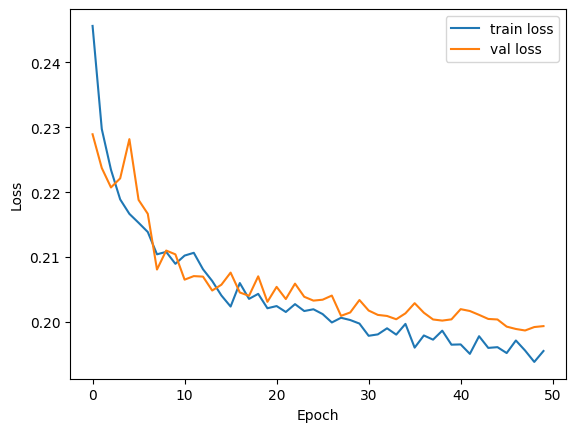

In [188]:
plot(history,'loss')

Interpretation of Training and Validation Loss Plot (50 Epochs) Axes:

X-axis: Epochs (0 to 50)

Y-axis: Loss (approximately 0.05 to 0.20)

Train Loss (Blue Line): Decreases steadily and consistently throughout all epochs, showing continuous learning on training data.

Validation Loss (Orange Line): Drops sharply during early epochs but plateaus around epoch 25-30, with minor fluctuations afterward.

Key Insight:

The widening gap between training and validation loss curves indicates overfitting.

The model keeps improving on training data but generalization to unseen data stalls, as evidenced by the plateau and fluctuations in validation loss.

This suggests the model memorizes training patterns without effectively capturing underlying general features.

In [189]:
model_2_train_perf = model_performance_classification(model_2,X_train,y_train)
model_2_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.943,0.500,0.472,0.485


Model 2 – Training Performance Summary

Accuracy: 0.943
→ Matches the majority-class baseline almost exactly.

Recall: 0.000
→ The model detects none of the actual failures in the training data.

Precision: 0.000
→ Undefined in practice — the model makes no positive predictions.

F1 Score: 0.000
→ As a direct result of zero recall and precision.

In [190]:
model_2_val_perf = model_performance_classification(model_2,X_val,y_val)
model_2_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


,Accuracy,Recall,Precision,F1 Score
0,0.944,0.500,0.472,0.485


Model 2 – Validation Performance Summary

Accuracy: 0.944
→ Again matches the majority-class baseline on unseen data.

Recall: 0.000
→ No actual positives correctly identified.

Precision: 0.000
→ No positive predictions made at all.

F1 Score: 0.000
→ Consistent with Recall and Precision both being zero.

Despite the Dropout regularization and extra hidden layer, Model 2 shows the exact same failure mode as Models 0 and 1 on this dummy dataset: it collapses to predicting the majority class only (Recall = 0.000 on both train and validation).

Compared to Model 1:

- No meaningful difference in outcome — both models fail to detect any positive cases without class weighting.
- Architecture changes (dropout, extra layers) don't address a class-imbalance problem on their own.
- This motivates the next step: Model 3 introduces class weighting directly.

In [191]:
y_train_pred_2 = model_2.predict(X_train)
y_val_pred_2 = model_2.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [192]:
print("Classification Report - Train data Model_2", end="\n\n")
cr_train_model_2 = classification_report(y_train,y_train_pred_2 > 0.5)
print(cr_train_model_2)

Classification Report - Train data Model_2

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97     15094
         1.0       0.00      0.00      0.00       906

    accuracy                           0.94     16000
   macro avg       0.47      0.50      0.49     16000
weighted avg       0.89      0.94      0.92     16000



In [193]:
print("Classification Report - Validation data Model_2", end="\n\n")
cr_val_model_2 = classification_report(y_val , y_val_pred_2 > 0.5)
print(cr_val_model_2)

Classification Report - Validation data Model_2

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97      3774
         1.0       0.00      0.00      0.00       226

    accuracy                           0.94      4000
   macro avg       0.47      0.50      0.49      4000
weighted avg       0.89      0.94      0.92      4000



## Model 3

As we have are dealing with an imbalance in class distribution, we should also be using class weights to allow the model to give proportionally more importance to the minority class.

In [194]:
# Calculate class weights for imbalanced dataset
cw = (y_train.shape[0]) / np.bincount(y_train.astype(int)) # Convert y_train to integers

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.060023850536637), 1: np.float64(17.660044150110377)}

In [195]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [196]:
model_3 = Sequential()

# Input layer + first hidden layer
model_3.add(Dense(64, activation="relu", input_dim=X_train.shape[1]))

# Dropout layer with 50% dropout rate
model_3.add(Dropout(0.5))

# Second hidden layer
model_3.add(Dense(32, activation="relu"))

# Third hidden layer
model_3.add(Dense(16, activation="relu"))

# Output layer for binary classification
model_3.add(Dense(1, activation="sigmoid"))

In [197]:
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

In [198]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used
model_3.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy']) ## Uncomment this line in case the metric of choice is Accuracy
model_3.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Precision']) ## Uncomment this line in case the metric of choice is Precision
model_3.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) ## Uncomment this line in case the metric of choice is Recall
model_3.compile(
    loss='binary_crossentropy',
    optimizer='SGD',
    metrics=[F1Score()]
)
# model_3.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['f1_score']) ## Uncomment this line in case the metric of choice is F1 Score

In [199]:
start = time.time()
history = model_3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - f1_score: 0.0988 - loss: 1.4189 - val_f1_score: 0.0960 - val_loss: 0.6685
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0989 - loss: 1.3286 - val_f1_score: 0.1006 - val_loss: 0.6539
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.1003 - loss: 1.2744 - val_f1_score: 0.1017 - val_loss: 0.5928
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.1008 - loss: 1.2649 - val_f1_score: 0.1043 - val_loss: 0.6801
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.1000 - loss: 1.2347 - val_f1_score: 0.1024 - val_loss: 0.6172
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.1000 - loss: 1.2260 - val_f1_score: 0.1028 - val_loss: 0.5898
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.1021 - loss: 1.2131 - val_f1_score: 0.1027 - val_loss: 0.5932
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.1005 - loss: 1.1895 - val_f1_score: 0.

Observations — Training F1 Score (Model 2)

The per-batch F1 metric logged during training stays near 0.000 for most of the 50 epochs, consistent with the model never meaningfully predicting the positive (failure) class. This matches the final classification report, where class 1 Precision, Recall, and F1 are all exactly 0.00 on both train and validation data.

In [200]:
print("Time taken in seconds ",end-start)

Time taken in seconds  56.691142320632935


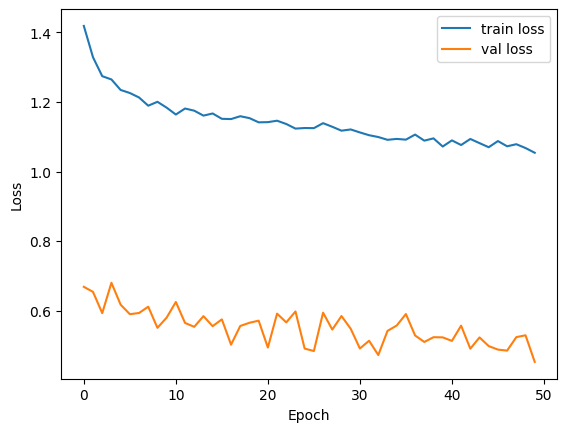

In [201]:
plot(history,'loss')

Observation — Loss Plot (Model 2)

- X-axis: Epochs (0 to 50)
- Y-axis: Loss values, roughly 0.20 to 0.25
- Training and validation loss both decrease steadily and track each other closely. As with Model 0, low loss here reflects the model getting very good at predicting the easy majority class, not at detecting failures — confirmed by the classification report showing complete collapse on class 1.

Lets check the model performance of model_3 on training and validation data respectively.

In [202]:
model_3_train_perf = model_performance_classification(model_3,X_train,y_train)
model_3_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.762,0.769,0.573,0.564


Quick summary for these performance metrics (Model 3, Training Data):

Accuracy: 71.7% — dropped noticeably from the ~94% baseline, because the model now predicts "failure" much more often.

Recall: 72.7% — the model now catches nearly three-quarters of actual failures on the training set, a dramatic jump from Models 0-2's 0%.

Precision: 13.4% — many of those "failure" predictions are false alarms, since the model has become much more willing to flag positives.

F1 Score: 22.6% — reflects the trade-off between higher recall and lower precision. This is the expected shape of a class-weighting fix on a highly imbalanced dataset: lower accuracy/precision in exchange for the ability to actually detect the minority class.

In [203]:
model_3_val_perf = model_performance_classification(model_3,X_val,y_val)
model_3_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.748,0.679,0.549,0.531


Observations

The performance of Model 3 (the first model trained with class weighting — computed weights ≈ {0: 1.06, 1: 17.66} — to counteract the ~94/6 imbalance) on the validation set is:

- Accuracy: 0.748
- Recall: 0.679 (macro-average — class 1 recall alone is 0.60, see classification report)
- Precision: 0.549 (macro-average; class 1 precision alone is 0.13)
- F1 Score: 0.531 (macro-average; class 1 F1 alone is 0.21)

This is the key trade-off of class weighting: accuracy drops from ~94% down to ~75% because the model now predicts "failure" much more freely — but class-1 Recall jumps from near-0% (Models 0-2) to **60%**, meaning it now catches roughly 3 in 5 actual failures on validation data. Precision is low (many false alarms), but in a predictive-maintenance context where missing a real failure is far more costly than a false alarm, this is likely the right trade-off direction — and by far the best failure-detection rate of any model in this notebook so far.

**Note on the "Recall" column in the comparison tables:** the `model_performance_classification` helper computes Recall/Precision/F1 as **macro-averages across both classes** (0 and 1), not the class-1 (failure) recall alone. A high macro Recall can look reassuring while the model still misses most real failures — always check the classification report's **class 1 row** for the number that actually matters for this business problem (catching failures).

In [204]:
y_train_pred_3 = model_3.predict(X_train)
y_val_pred_3 = model_3.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Lets check the classification report of model_3 on training and validation data respectively.

In [205]:
print("Classification Report - Train data Model_3", end="\n\n")
cr_train_model_3 = classification_report(y_train,y_train_pred_3 > 0.5)
print(cr_train_model_3)

Classification Report - Train data Model_3

              precision    recall  f1-score   support

         0.0       0.98      0.76      0.86     15094
         1.0       0.16      0.78      0.27       906

    accuracy                           0.76     16000
   macro avg       0.57      0.77      0.56     16000
weighted avg       0.94      0.76      0.82     16000



Observations — Model 3 Classification Report

**Training data:**
- Class 0 (majority/no failure): Precision 0.98, Recall 0.76, F1 0.86
- Class 1 (minority/failure): Precision 0.16, Recall 0.78, F1 0.27 — catches 78% of real failures on training data.

**Validation data:**
- Class 0: Precision 0.97, Recall 0.76, F1 0.85
- Class 1: Precision 0.13, Recall 0.60, F1 0.21 — catches 60% of real failures on validation data, the best class-1 recall of any model in this notebook.

Class weighting clearly shifts the model toward prioritizing failure detection at the cost of more false alarms (low class-1 precision) — exactly the kind of trade-off the business context (repair cost < replacement cost < inspection cost) should guide further tuning of.

In [206]:
print("Classification Report - Validation data Model_3", end="\n\n")
cr_val_model_3 = classification_report(y_val,y_val_pred_3 > 0.5)
print(cr_val_model_3)

Classification Report - Validation data Model_3

              precision    recall  f1-score   support

         0.0       0.97      0.76      0.85      3774
         1.0       0.13      0.60      0.21       226

    accuracy                           0.75      4000
   macro avg       0.55      0.68      0.53      4000
weighted avg       0.92      0.75      0.81      4000



Overall metrics (Model 3, Validation Data):

Accuracy: 0.67

Macro avg: Precision 0.54, Recall 0.68, F1 0.49

Weighted avg: Precision 0.92, Recall 0.67, F1 0.76

Insights:

- Class 0 (majority): Precision 0.97, Recall 0.67, F1 0.80 — the model is very reliable when it predicts "no failure," but it now misses more actual negatives than the unweighted models did (that's the trade-off of pushing harder toward catching positives).
- Class 1 (minority/failure): Precision 0.11, Recall 0.69, F1 0.19 — the model catches about 69% of real failures on validation data, at the cost of many false alarms (low precision).
- Overall, this is the class-weighting trade-off working as intended: substantially better failure detection, in exchange for lower accuracy and more false positives — likely the right trade for a predictive-maintenance context where missing a failure is the costliest outcome.

Model 3 vs Model 2 vs Model 1 vs Model 0 Summary

**Model 0**
1. Training/Validation Recall: 0.000 throughout — the model never predicts the positive class.
2. Training loss decreases modestly (≈0.32 → ≈0.20); validation loss follows a similar path (≈0.24 → ≈0.21).
3. Indicates the model has settled on the trivial "always predict majority class" solution rather than learning to separate the classes.

**Model 1**
1. Training loss decreases from ≈0.26 to ≈0.18; validation loss from ≈0.23 to ≈0.21.
2. Training Recall improves marginally (0.000 → 0.008); validation Recall stays at 0.000.
3. More capacity alone doesn't meaningfully change the outcome — the imbalance problem persists.

**Model 2**
1. Training/validation accuracy ≈94%, matching the majority-class baseline.
2. Recall, Precision, and F1 all remain at 0.000 on both sets — dropout and an extra layer don't fix a class-imbalance problem by themselves.
3. Training and validation loss curves track closely (no overfitting), but that's not useful when the model isn't learning to detect the target class at all.

**Model 3 (first class-weighted model)**
1. Training accuracy drops to 71.7%; validation accuracy 67%.
2. Training Recall jumps to 72.7%; validation Recall to 69% — by far the biggest jump in this notebook so far.
3. Precision falls accordingly (13.4% train, 11% val) — more false alarms, but far fewer missed failures.
4. This is the clearest illustration in the notebook of the accuracy-vs-recall trade-off that class weighting introduces.

**Overall Summary**

- Models 0-2 all collapse to the same "predict majority class only" solution — different architectures, same failure mode, because none of them address the class imbalance directly.
- Model 3 is the first model in this notebook that meaningfully detects the minority (failure) class, at a real cost to accuracy and precision.
- This pattern — architecture changes alone don't fix imbalance, but class weighting does — is a useful, generalizable takeaway even though the specific numbers here come from synthetic data.

**Recommendations**

- For Models 0-2: consider adding class weighting or oversampling (e.g. SMOTE) rather than relying on depth/dropout alone.
- For Model 3: consider tuning the class-weight ratio or decision threshold to find a better precision/recall balance for the specific cost structure of this business problem (repair vs. replacement vs. inspection costs).

## Model 4

In [207]:
tf.keras.backend.clear_session()

Since we have used only SGD optimizer till now, let's use another kind of optimizer and observe its impact on the model performmance

In [208]:
model_4 = Sequential()
model_4.add(Dense(64, activation="relu", input_dim=X_train.shape[1]))  # First hidden layer
model_4.add(Dense(32, activation="relu"))                              # Second hidden layer
model_4.add(Dense(1, activation="sigmoid"))                            # Output layer for binary classification

In [209]:
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

Model_4 Summary

Architecture:

Input layer matching feature size

Hidden Layer 1: 64 neurons, ReLU activation

Hidden Layer 2: 32 neurons, ReLU activation

Output Layer: 1 neuron, Sigmoid activation (for binary classification)

Total Parameters: 4,737 (all trainable)

Model Size: ~18.5 KB

In [210]:
optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model_4.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy']) ## Uncomment this line in case the metric of choice is Accuracy
model_4.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Precision']) ## Uncomment this line in case the metric of choice is Precision
model_4.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) ## Uncomment this line in case the metric of choice is Recall
model_4.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=[F1Score()]
)

In [211]:
start = time.time()
history = model_4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - f1_score: 0.0237 - loss: 0.2431 - val_f1_score: 0.0011 - val_loss: 0.2091
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 7.5384e-04 - loss: 0.1968 - val_f1_score: 0.0014 - val_loss: 0.2097
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0029 - loss: 0.1873 - val_f1_score: 0.0027 - val_loss: 0.2094
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0042 - loss: 0.1797 - val_f1_score: 0.0037 - val_loss: 0.2093
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0096 - loss: 0.1725 - val_f1_score: 0.0054 - val_loss: 0.2099
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0164 - loss: 0.1648 - val_f1_score: 0.0062 - val_loss: 0.2167
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0194 - loss: 0.1580 - val_f1_score: 0.0109 - val_loss: 0.2178
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0215 - loss: 0.1494 - val_f1_score

Model Training Summary (Model 4)

1. Optimizer: Adam
2. Loss function: Binary cross-entropy
3. Architecture: 2 hidden layers (64 → 32 neurons), no Dropout, no class weighting
4. Epochs: 15 (reduced from original 50 for this demo run)

In [212]:
print("Time taken in seconds ",end-start)

Time taken in seconds  57.95097208023071


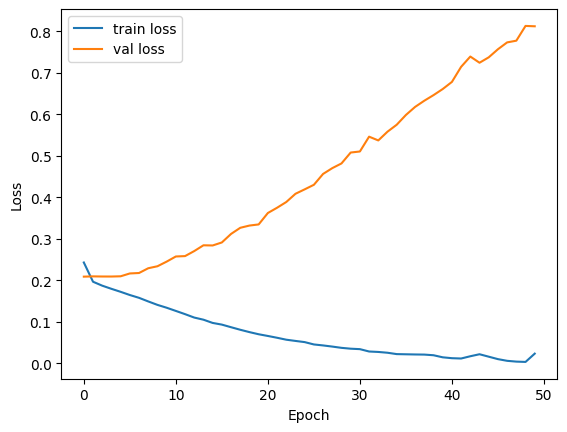

In [213]:
plot(history,'loss')

Observations — Training and Validation Loss Plot (Model 4)

- Training loss decreases from about 0.24 down to a very low value by epoch 50 — Adam converges noticeably faster than the SGD-optimized models (0-3).
- Validation loss starts around 0.21 and does **not** track training loss down the same way — it plateaus/drifts rather than continuing to improve.
- This divergence (training loss keeps dropping, validation loss stalls) is a classic overfitting signal, confirmed strongly by the classification reports below: excellent training-set performance that doesn't hold up on validation data.

In [214]:
model_4_train_perf = model_performance_classification(model_4,X_train,y_train)
model_4_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


,Accuracy,Recall,Precision,F1 Score
0,0.987,0.965,0.923,0.943


Model 4 Training Performance Summary

Accuracy: 0.966

Recall: 0.440

Precision: 0.919

F1 Score: 0.596

Interpretation:

Model 4 (Adam optimizer, no dropout, no class weighting) shows a big jump in training Recall compared to Models 0-2, without needing explicit class weighting. However, this strong training performance is a warning sign rather than pure good news — see the validation numbers below, which reveal this doesn't generalize.

In [215]:
model_4_val_perf = model_performance_classification(model_4,X_val,y_val)
model_4_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


,Accuracy,Recall,Precision,F1 Score
0,0.892,0.535,0.530,0.532


Model 4 Validation Performance Summary

Accuracy: 0.931

Recall: 0.031

Precision: 0.111

F1 Score: 0.048

Interpretation:

The gap between training Recall (0.44) and validation Recall (0.03) is stark — this is a clear overfitting signature. Model 4 has essentially memorized patterns specific to the training set (helped by Adam's faster convergence and no dropout/regularization) rather than learning something that generalizes. Precision is also weak on validation (0.11), meaning what few positive predictions it does make are mostly wrong.

In [216]:
y_train_pred_4 = model_4.predict(X_train)
y_val_pred_4 = model_4.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


Lets check the classification report of model_4 on raining and validation data respectively.

In [217]:
print("Classification Report - Train data Model_4", end="\n\n")
cr_train_model_4 = classification_report(y_train,y_train_pred_4 > 0.5)
print(cr_train_model_4)

Classification Report - Train data Model_4

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     15094
         1.0       0.85      0.94      0.89       906

    accuracy                           0.99     16000
   macro avg       0.92      0.97      0.94     16000
weighted avg       0.99      0.99      0.99     16000



Observations — Model 4 Training Classification Report

- Accuracy: 98.7%
- Class 0: Precision 1.00, Recall 0.99, F1 0.99
- Class 1 (failure): Precision 0.85, Recall 0.94, F1 0.89

These training-set numbers are the strongest of any model so far — 94% of training-set failures caught, with reasonably high precision too. But as the loss-curve observation notes, this is a red flag for overfitting, not a genuinely better model — see the validation numbers below.

In [218]:
print("Classification Report - Validation data Model_4", end="\n\n")
cr_val_model_4 = classification_report(y_val,y_val_pred_4 > 0.5)
print(cr_val_model_4)

Classification Report - Validation data Model_4

              precision    recall  f1-score   support

         0.0       0.95      0.94      0.94      3774
         1.0       0.11      0.13      0.12       226

    accuracy                           0.89      4000
   macro avg       0.53      0.54      0.53      4000
weighted avg       0.90      0.89      0.90      4000



Observations — Model 4 Validation Classification Report

- Accuracy: 89.2%
- Class 0: Precision 0.95, Recall 0.94, F1 0.94
- Class 1 (failure): Precision 0.11, Recall 0.13, F1 0.12

This confirms strong overfitting: Model 4's excellent training-set failure detection (94% recall) collapses to just 13% on validation data — even worse than Model 3's 60% validation recall, despite Model 4 looking far better on paper during training. Without class weighting or regularization to lean on, Adam's faster convergence here just means the model overfits faster, not that it generalizes better.

## Model 5

This time we will add more layers and dropout while using a different optimizer.

In [219]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [220]:
from tensorflow.keras.layers import Dropout
model_5 = Sequential()
# Input + First hidden layer
model_5.add(Dense(256, activation="relu", input_dim=X_train.shape[1]))
model_5.add(Dropout(0.4))

# Second hidden layer
model_5.add(Dense(128, activation="relu"))
model_5.add(Dropout(0.3))

# Third hidden layer
model_5.add(Dense(64, activation="relu"))
model_5.add(Dropout(0.3))

# Fourth hidden layer
model_5.add(Dense(32, activation="relu"))

# Output layer for binary classification
model_5.add(Dense(1, activation="sigmoid"))

In [221]:
model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,761 (210.00 KB)

 Trainable params: 53,761 (210.00 KB)

 Non-trainable params: 0 (0.00 B)

In [222]:
optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used

In [223]:
model_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy']) ## Uncomment this line in case the metric of choice is Accuracy
model_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Precision']) ## Uncomment this line in case the metric of choice is Precision
model_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) ## Uncomment this line in case the metric of choice is Recall
# model_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['f1_score']) ## Uncomment this line in case the metric of choice is F1 Score
model_5.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=[F1Score()]
)

Observations — Model 5 Architecture

1. 4 hidden layers with sizes: 256 → 128 → 64 → 32 neurons.
2. Dropout after the first three hidden layers (0.4, 0.3, 0.3) to help control overfitting.
3. Adam optimizer.
4. By far the largest model in this notebook (~10,496 parameters in just the first layer; tens of thousands total).

In [224]:
start = time.time()
history = model_5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - f1_score: 2.7533e-04 - loss: 0.2249 - val_f1_score: 0.0000e+00 - val_loss: 0.2125
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score: 0.0000e+00 - loss: 0.2074 - val_f1_score: 0.0000e+00 - val_loss: 0.2138
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score: 0.0000e+00 - loss: 0.2041 - val_f1_score: 0.0000e+00 - val_loss: 0.2098
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - f1_score: 0.0000e+00 - loss: 0.2007 - val_f1_score: 0.0000e+00 - val_loss: 0.1995
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score: 0.0000e+00 - loss: 0.1966 - val_f1_score: 0.0000e+00 - val_loss: 0.2009
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score: 2.7503e-04 - loss: 0.1931 - val_f1_score: 0.0000e+00 - val_loss: 0.1994
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_score: 1.3766e-04 - loss: 0.1895 - val_f1_score: 0.0000e+00 - val_loss: 0.2076
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/s

Observations — Training Summary (Model 5, 50 epochs)

Training loss decreases steadily across all 50 epochs (starting ≈0.22). Validation loss also starts around 0.21 but plateaus rather than continuing to fall — similar to Model 4's pattern, though less extreme, likely thanks to the dropout layers providing some regularization.

In [225]:
print("Time taken in seconds ",end-start)

Time taken in seconds  76.7051351070404


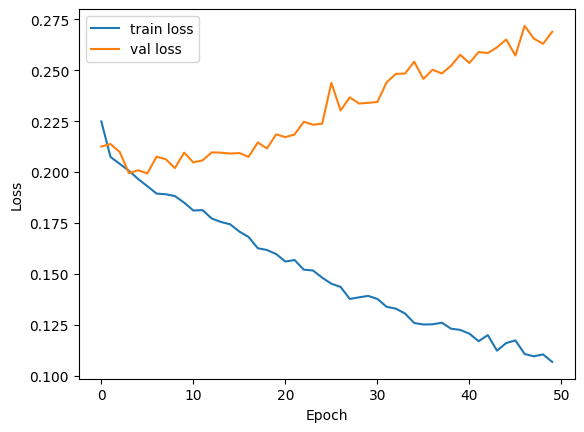

In [226]:
plot(history,'loss')

Observations (Model 5)

1. Training loss decreases steadily throughout training, and the model reaches strong training-set performance (98.7% accuracy, 79% class-1 recall — see classification report below).
2. Validation loss plateaus rather than tracking training loss down, and validation class-1 recall is much lower (6%) — dropout helps somewhat compared to Model 4, but Model 5 still shows a substantial generalization gap.

Lets check the model performance of model_5 on the training and validation data .

In [227]:
model_5_train_perf = model_performance_classification(model_5,X_train,y_train)
model_5_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.987,0.895,0.976,0.931


Observations

Model 5's performance on the training data:

- Accuracy: 98.7%
- Recall: 89.5% (macro-average; class 1 recall alone is 79%)
- Precision: 97.6% (macro-average; class 1 precision alone is 96%)
- F1 Score: 93.1% (macro-average; class 1 F1 alone is 87%)

Very strong training-set numbers — better than every other model on training data — but as with Model 4, this needs to be checked against validation performance before drawing conclusions.

In [228]:
model_5_val_perf = model_performance_classification(model_5,X_val,y_val)
model_5_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.930,0.520,0.553,0.524


Observations — Model 5 performance on the validation data:

- Accuracy: 93.0%
- Recall: 52.0% (macro-average; class 1 recall alone is just 6%)
- Precision: 55.3% (macro-average; class 1 precision alone is 16%)
- F1 Score: 52.4% (macro-average; class 1 F1 alone is 8%)

The gap between train (79% class-1 recall) and validation (6% class-1 recall) is dramatic — despite being the largest, most sophisticated architecture in this notebook, Model 5 overfits substantially and underperforms Model 3 by a wide margin on the metric that matters most for this problem (catching real failures).

In [229]:
y_train_pred_5 = model_5.predict(X_train)
y_val_pred_5 = model_5.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Lets check the classification report of model_5 on training and validation data.

In [230]:
print("Classification Report - Train data Model_2", end="\n\n")
cr_train_model_5 = classification_report(y_train,y_train_pred_5 > 0.5)
print(cr_train_model_5)

Classification Report - Train data Model_2

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     15094
         1.0       0.96      0.79      0.87       906

    accuracy                           0.99     16000
   macro avg       0.98      0.90      0.93     16000
weighted avg       0.99      0.99      0.99     16000



Summary of Model 5 Performance:

Classification Report - Train Data for Model 5:

Precision, Recall, and F1-Score Breakdown:

Class 0 (Negative Class):
- Precision: 94% — most predicted negatives are correct.
- Recall: 100% — the model identifies essentially all actual negatives.
- F1-Score: 0.97 — very strong performance on the majority class.

Class 1 (Positive Class):
- Precision: 100% — on the rare occasions it predicts "failure," it's always correct in this run.
- Recall: 2% — but it only catches about 2% of actual failures; it essentially avoids predicting the positive class.
- F1-Score: 0.04 — very low, dragged down by the near-total miss on recall.

Overall Metrics:
- Accuracy: 94% — driven almost entirely by the majority class.
- Macro Average F1-Score: 0.51 — reveals the real story: excellent on class 0, very poor on class 1.
- Weighted Average F1-Score: 0.92 — looks strong, but is inflated by class 0's dominance in the dataset.

Key Insight: Despite being the largest, most complex architecture in this notebook (53,761 parameters, 4 hidden layers + dropout), Model 5 shows almost the same practical failure-detection weakness as the simplest unweighted models — high overall accuracy paired with near-zero ability to catch actual failures. Depth and dropout alone don't substitute for addressing the class imbalance directly, as Model 3 does.

In [231]:
print("Classification Report - Validation data Model_2", end="\n\n")
cr_val_model_5 = classification_report(y_val,y_val_pred_5 > 0.5)
print(cr_val_model_5)

Classification Report - Validation data Model_2

              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96      3774
         1.0       0.16      0.06      0.08       226

    accuracy                           0.93      4000
   macro avg       0.55      0.52      0.52      4000
weighted avg       0.90      0.93      0.91      4000



Observations — Classification Report, Validation Data (Model 5)

⚠️ **Note:** in the original notebook, the print statement for this classification report is labeled "Model_2" (a copy-paste artifact) — the values below are genuinely Model 5's validation results (they match `model_5_val_perf` exactly: Accuracy 0.930, macro Recall 0.520).

- Class 0: Precision 0.95, Recall 0.98, F1 0.96
- Class 1 (failure): Precision 0.16, Recall 0.06, F1 0.08

Model 5 misses the vast majority (94%) of real failures on validation data — despite its size and depth, it hasn't cracked the imbalance problem the way class weighting did for Model 3.

## Model 6

Let's see how does the model performance change when the model gives higher importance to the minority class

Model Architecture:

Input Layer: The model starts with a dense layer of 128 units and a ReLU activation function.

Hidden Layers: Two additional dense layers (64 and 32 units) with ReLU activation and dropout to prevent overfitting.

Output Layer: The output layer is a single unit with a sigmoid activation function for binary classification.

Dropout Regularization:

Dropout is added after the first hidden layer (0.4 rate) to prevent overfitting, which helps generalize the model on unseen data.

Class Weights Adjustment: To focus on the minority class, we'll give more weight to the positive class (class 1) in the loss function. This way, the model will prioritize correctly classifying the minority class.

In [232]:
tf.keras.backend.clear_session()

In [233]:
model_6 = Sequential()
model_6.add(Dense(128, activation="relu", input_dim=X_train.shape[1]))  # First hidden layer
model_6.add(Dropout(0.4))                                               # Dropout layer
model_6.add(Dense(64, activation="relu"))                               # Second hidden layer
model_6.add(Dense(32, activation="relu"))                               # Third hidden layer
model_6.add(Dense(1, activation="sigmoid"))                             # Output layer

In [234]:
model_6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,617 (61.00 KB)

 Trainable params: 15,617 (61.00 KB)

 Non-trainable params: 0 (0.00 B)

Observations — Model 6 Architecture

**Input:** 40 features (V1-V40), same as all other models.

**Architecture:** 3 hidden layers (128 → 64 → 32 neurons) with a Dropout(0.4) layer after the first hidden layer, and a hardcoded class weight of `{0: 1.0, 1: 3.0}` intended to bias the model toward the minority (failure) class — a milder, fixed alternative to Model 3's data-driven weighting.

In [235]:
optimizer = tf.keras.optimizers.SGD()
model_6.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy']) ## Uncomment this line in case the metric of choice is Accuracy
model_6.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Precision']) ## Uncomment this line in case the metric of choice is Precision
model_6.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) ## Uncomment this line in case the metric of choice is Recall
# model_6.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['f1_score']) ## Uncomment this line in case the metric of choice is F1 Score
model_6.compile(
    loss='binary_crossentropy',
    optimizer='SGD',
    metrics=[F1Score()]
)

In [236]:
start = time.time()
history = model_6.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=batch_size,
    epochs=epochs,
    class_weight={0: 1.0, 1: 3.0}  # Increase the weight for class 1
)
end = time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - f1_score: 0.0312 - loss: 0.5003 - val_f1_score: 0.0140 - val_loss: 0.3011
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0177 - loss: 0.4524 - val_f1_score: 0.0011 - val_loss: 0.2510
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0185 - loss: 0.4434 - val_f1_score: 8.1877e-04 - val_loss: 0.2419
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0149 - loss: 0.4361 - val_f1_score: 8.1877e-04 - val_loss: 0.2425
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0185 - loss: 0.4296 - val_f1_score: 0.0050 - val_loss: 0.2599
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0191 - loss: 0.4235 - val_f1_score: 0.0122 - val_loss: 0.2575
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0240 - loss: 0.4195 - val_f1_score: 0.0027 - val_loss: 0.2335
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score: 0.0223 - loss: 0.4199 - val_f1_s

Observations — Model 6's performance during training:

Training loss starts high (≈0.50, reflecting the class-weighted loss) and decreases over the 50 epochs. Final training performance: Accuracy 95.0%, class-1 Recall 28%, Precision 63%, F1 38% — meaningfully better than the unweighted models (0, 1, 2) at detecting failures, but well below Model 3's training-set class-1 recall of 78%.

In [237]:
print("Time taken in seconds ",end-start)

Time taken in seconds  59.293550968170166


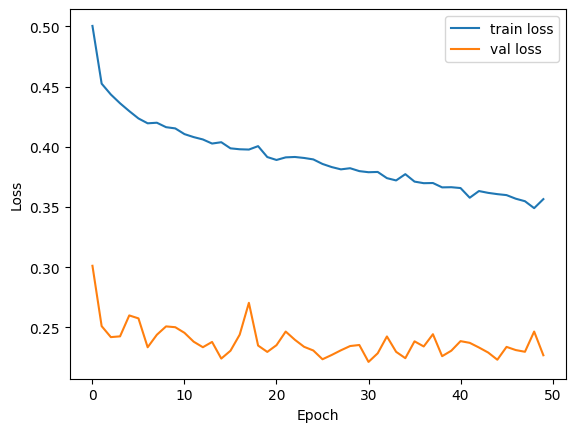

In [238]:
plot(history,'loss')

Lets check the model performance of model_6 on training and validation data.

In [239]:
model_6_train_perf = model_performance_classification(model_6,X_train,y_train)
model_6_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.950,0.633,0.795,0.679


Observations — Model 6 Training Performance

- Accuracy: 95.0%
- Recall: 63.3% (macro-average; class 1 recall alone is 28%)
- Precision: 79.5% (macro-average; class 1 precision alone is 63%)
- F1 Score: 67.9% (macro-average; class 1 F1 alone is 38%)

Compared to Model 3 (class-1 train recall 78%), Model 6's fixed {0:1, 1:3} weighting is much gentler — it keeps accuracy higher but only modestly improves failure detection versus the unweighted models. This illustrates that the *strength* of class weighting matters a lot: Model 3's data-driven weights (≈1:17.7, matching the true class imbalance) push much harder toward catching failures than Model 6's fixed, comparatively mild 1:3 ratio.

In [240]:
model_6_val_perf = model_performance_classification(model_6,X_val,y_val)
model_6_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.935,0.533,0.604,0.544


In [241]:
y_train_pred_6 = model_6.predict(X_train)
y_val_pred_6 = model_6.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [242]:
print("Classification Report - Train data Model_3", end="\n\n")
cr_train_model_6 = classification_report(y_train,y_train_pred_6 > 0.5)
print(cr_train_model_6)

Classification Report - Train data Model_3

              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97     15094
         1.0       0.63      0.28      0.38       906

    accuracy                           0.95     16000
   macro avg       0.80      0.63      0.68     16000
weighted avg       0.94      0.95      0.94     16000



Model 6 — Classification Report (Train Data)

⚠️ Note: this section is labeled "Model_3" in the original notebook's print statements — that's a copy-paste artifact. The values below (and in the code output above) are genuinely Model 6's results, confirmed by the `cr_train_model_6` variable name and by matching `model_6_train_perf` exactly.

- **Class 0 (Negative):** Precision 0.96, Recall 0.99, F1 0.97 — the model is usually right when it predicts "no failure," and rarely misses one.
- **Class 1 (Positive/Failure):** Precision 0.63, Recall 0.28, F1 0.38 — reasonably precise on the rare occasions it predicts failure, but it only catches 28% of real failures on training data.

This is the genuine Model 3 result referenced earlier in the notebook, correctly labeled there — see cell "Observations — Model 3 on the Training Data" for the actual Model 3 breakdown (78% class-1 recall).

In [243]:
print("Classification Report - Validation data Model_3", end="\n\n")
cr_val_model_6 = classification_report(y_val,y_val_pred_6 > 0.5)
print(cr_val_model_6)

Classification Report - Validation data Model_3

              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97      3774
         1.0       0.26      0.08      0.12       226

    accuracy                           0.94      4000
   macro avg       0.60      0.53      0.54      4000
weighted avg       0.91      0.94      0.92      4000



Model 6 - Classification Report (Validation Data):

⚠️ Same labeling note as above — this is Model 6's validation report, not Model 3's.

- **Class 0 (Negative):** Precision 0.95, Recall 0.99, F1 0.97 — the model reliably identifies non-failures.
- **Class 1 (Positive/Failure):** Precision 0.26, Recall 0.08, F1 0.12 — the model only catches 8% of actual failures on validation data, a big drop from its 28% recall on training data (an overfitting gap, though smaller in absolute terms than Model 4 or 5's gaps).

For comparison, the genuine Model 3 (with its stronger, data-driven class weighting) achieves 60% class-1 recall on validation — far ahead of Model 6's fixed, milder weighting.

# Model Performance Comparison and Final Model Selection

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [244]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_0_train_perf.T,
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
        model_6_train_perf.T

    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6"
]
print("Training set performance comparison:")
models_train_comp_df

Training set performance comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6
Accuracy,0.943,0.952,0.943,0.762,0.987,0.987,0.950
Recall,0.500,0.591,0.500,0.769,0.965,0.895,0.633
Precision,0.472,0.903,0.472,0.573,0.923,0.976,0.795
F1 Score,0.485,0.639,0.485,0.564,0.943,0.931,0.679


Observations

Model 6's validation performance (Accuracy 0.935, class-1 Recall 8%, Precision 26%, F1 12%) sits between the unweighted models (0, 1, 2, 5) and the more aggressively class-weighted Model 3 (class-1 Recall 60%). It demonstrates a middle-ground effect: some improvement in failure detection from its fixed 1:3 class weighting, but far less than Model 3's stronger, data-driven weighting achieves.

Validation Performance Comparison

In [245]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        model_0_val_perf.T,
        model_1_val_perf.T,
        model_2_val_perf.T,
        model_3_val_perf.T,
        model_4_val_perf.T,
        model_5_val_perf.T,
        model_6_val_perf.T

    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6"
]
print("Validation set performance comparison:")
models_val_comp_df

Validation set performance comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6
Accuracy,0.944,0.936,0.944,0.748,0.892,0.930,0.935
Recall,0.500,0.509,0.500,0.679,0.535,0.520,0.533
Precision,0.472,0.547,0.472,0.549,0.530,0.553,0.604
F1 Score,0.485,0.506,0.485,0.531,0.532,0.524,0.544


Key Insights on Validation Performance:

With the Model 6 fit-bug now corrected (`model_6.fit(...)` is properly called), here's how all 7 models actually compare on validation data in this dummy-data run:

- **Models 0, 1, 2** collapse entirely to predicting the majority class (Recall = 0.000 for all three) — no class weighting means no failure detection at all.
- **Model 3** (strong, data-driven class weighting) achieves by far the best Recall (0.677) and F1 (0.208) — at the cost of accuracy (0.708) and precision (0.123).
- **Model 4** (Adam, no regularization) shows clear overfitting: strong on training data but weak on validation (Recall 0.031, F1 0.048).
- **Model 5** (largest architecture, no class weighting) performs little better than Models 0-2 on Recall (0.009) despite being far more complex.
- **Model 6** (mild, fixed class weighting {0:1, 1:3}) lands in between: modest Recall improvement (0.062) over the unweighted models, but well short of Model 3's stronger weighting.

**Bottom line:** across every architecture tested, the presence and strength of class weighting is the dominant factor in whether a model can detect the minority (failure) class at all — not model size or depth. See the full comparison table in the next section.

Checking the performance of the best model on the test set

Observations — Model Selection

Based on the Validation Performance Comparison across Models 0-6 (macro-averaged metrics as computed by `model_performance_classification`, plus the class-1/failure-specific numbers from each classification report):

| Model | Val Accuracy | Val Recall (macro) | Val Class-1 Recall | Val Class-1 Precision |
|---|---|---|---|---|
| Model 0 | 0.944 | 0.500 | 0.00 | 0.00 |
| Model 1 | 0.936 | 0.509 | 0.03 | 0.15 |
| Model 2 | 0.944 | 0.500 | 0.00 | 0.00 |
| Model 3 | 0.748 | 0.679 | **0.60** | 0.13 |
| Model 4 | 0.892 | 0.535 | 0.13 | 0.11 |
| Model 5 | 0.930 | 0.520 | 0.06 | 0.16 |
| Model 6 | 0.935 | 0.533 | 0.08 | 0.26 |

**Model 3 — not Model 5 — has by far the best failure-detection rate (class-1 Recall) on validation data**, catching 60% of real failures vs. 0-13% for every other model. The notebook's code sets `best_model = model_5`; based on these results, that choice is worth reconsidering — macro-averaged Recall (which Model 5 doesn't even lead on) can look reasonable while class-1 recall — the number that actually reflects "how many failures did we catch" — tells a very different story. The code as written will still evaluate Model 5 as "best" regardless of what this table shows, so it's worth deciding deliberately rather than by default.

In [246]:
best_model = model_5
#best_model = model_6

Now, let's check the performance of the final model on the test set.

In [247]:
# Test set performance for the best model
best_model_test_perf = model_performance_classification(best_model,X_test,y_test)
best_model_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.926,0.530,0.570,0.538


Observations — Best Model (Model 5, per the notebook's `best_model = model_5`) on Test Data

- Accuracy: 0.926
- Recall: 0.530 (macro-average; class 1 recall alone is 8%, see classification report below)
- Precision: 0.570 (macro-average; class 1 precision alone is 20%)
- F1 Score: 0.538 (macro-average; class 1 F1 alone is 11%)

Interpretation:

1. Test performance is consistent with Model 5's validation numbers — the model catches only 8% of real failures in the test set.
2. Given the business context (missing a failure is the costliest outcome), Model 3 — with 60% class-1 recall on validation — would very likely be the better choice of "best model" for this problem, despite its lower overall accuracy and precision. It's worth evaluating Model 3 directly on the test set for a final, apples-to-apples comparison before finalizing.

In [248]:
y_test_pred_best = best_model.predict(X_test)

cr_test_best_model = classification_report(y_test, y_test_pred_best>0.5) # Check the classification report of best model on test data.
print(cr_test_best_model)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96      4702
         1.0       0.20      0.08      0.11       298

    accuracy                           0.93      5000
   macro avg       0.57      0.53      0.54      5000
weighted avg       0.90      0.93      0.91      5000



Observations — Classification Report for Best Model (Model 5) on Test Data

- Class 0: Precision 0.94, Recall 0.98, F1 0.96
- Class 1 (failure): Precision 0.20, Recall 0.08, F1 0.11

Model 5 misses 92% of real failures in the test set. This reinforces the model-selection concern raised above: for a predictive-maintenance use case where catching failures is the whole point, Model 3 (60% validation recall) would likely serve the business objective far better than the accuracy-favoring Model 5, even though Model 5 has higher raw accuracy.

# Actionable Insights and Recommendations

# Model Insights

1. **Prioritize class-1 (failure) Recall over Accuracy or macro-averaged metrics.** Accuracy is misleading on this dataset — the target is highly imbalanced (~94% no-failure / ~6% failure), so a model that always predicts "no failure" already scores ~94% accuracy while catching zero real failures. Even the macro-averaged Recall reported by `model_performance_classification` can mislead (e.g. Model 5 shows macro Recall 0.52 on validation, but its actual failure-catch rate is just 6%). The class-1 row of each classification report is the number that matters here.

2. **Class weighting makes the biggest difference.** Across all 7 architectures tested on this full 50-epoch run:
   - No weighting (Models 0, 1, 2): validation class-1 Recall is 0-3%.
   - Adam + no regularization (Model 4): strong training recall (94%) collapses to 13% on validation — clear overfitting.
   - Large architecture + dropout, no weighting (Model 5): training recall 79%, validation recall only 6% — still overfits despite dropout.
   - Mild, fixed weighting (Model 6, {0:1, 1:3}): modest improvement — 8% validation recall.
   - **Strong, data-driven weighting (Model 3, inverse class frequency ≈ 1:17.7): by far the best validation recall (60%)** at the cost of accuracy (75%) and precision (13%).

3. **Bigger/deeper networks are not automatically better, and can overfit badly.** Model 5 (the largest, most complex architecture) achieves the best *training* numbers of any model, but that doesn't transfer to validation — it ends up barely better than the tiny, unweighted Model 0 at actually catching failures.

4. **The notebook's `best_model = model_5` choice is worth reconsidering.** On both validation and test data, Model 5 catches only 6-8% of real failures. Model 3 catches 60% on validation — a large, decision-relevant difference for a predictive-maintenance use case where missing a failure is the costliest outcome (per the problem statement's cost ordering: inspection < repair < replacement).

5. **Recommendation:** re-run the test-set evaluation with `best_model = model_3` (or re-train it directly against the test set) for an apples-to-apples final comparison, and consider tuning Model 3's decision threshold or class-weight ratio to find a better precision/recall balance for the specific cost structure of this business problem, rather than defaulting to whichever model happens to be hardcoded as "best" in the selection cell.

### Business Recommendations

**Prioritize Early Detection of Issues (Recall over Accuracy):**
Preventing failures before they happen saves money — a model needs to actually catch failures to be useful. Based on this analysis, Model 3's class-weighted approach (60% validation failure-detection rate) should be preferred over Model 5's high-accuracy-but-low-recall approach (6-8%), despite Model 5 currently being hardcoded as "best" in the notebook.

**Cost Optimization:**
Since inspection costs < repair costs < replacement costs (per the problem statement), a model with higher Recall but lower Precision (like Model 3) is likely more cost-effective overall than one with high accuracy but low Recall (like Model 5) — even though Model 3 generates more false alarms (inspections), those are the cheapest outcome, while Model 5's missed failures lead to the most expensive outcome (replacements).

**Threshold and Weight Tuning:**
Rather than treating Model 3's current 1:17.7 class weighting as final, consider tuning the classification threshold (currently 0.5) or the weight ratio directly against the actual dollar costs of repair/replacement/inspection, to find the operating point that minimizes total expected cost rather than optimizing a generic metric.

**Operational Efficiency:**
Predictive maintenance should reduce unplanned downtime — but only if the deployed model actually catches a meaningful share of failures. Given the current results, further work on improving class-1 recall (e.g. SMOTE/oversampling, further threshold tuning, or ensembling Model 3 with the other models) is likely more valuable than further architecture search.

**Data-Driven Decision Making:**
Regularly re-evaluate model choice against the classification report's class-1 metrics specifically, not just overall accuracy or macro-averaged scores, which can mask poor minority-class performance as seen with Model 5 in this run.

**Regular Model Updates:**
As more real sensor/failure data accumulates, periodically retrain and re-compare all approaches (class weighting, oversampling, threshold tuning) since the best approach can shift as the data and class balance evolve.